## Balaji Fastfood
Moch Fadlilah Rahmadi
Data Analyst dibimbing.id offline batch 3

In [1]:
#Step 0, siapkan tools yang ingin dipakai/ import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import RobustScaler

### Import Data

In [2]:
#step 1, insert data balaji ff sales
data_ff = pd.read_csv(r'C:\Users\Fadlilah\Downloads\Balaji Fast Food Sales (tb & fadli).csv') #memanggil data ff
data_ff #hal yang pertama kali dilakukan ialah mengimpor data yang akan digunakan sebagai langkah awal analisa.
# data yang saya import merupakan data yang sudah saya download dan saya simpan di lokal dan saya memanggil data tersebut dengan pandas dengan format panggil csv

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,1,07-03-2022,Aalopuri,Fastfood,20,13,260,NaN,Mr.,Night
1,2,8/23/2022,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon
2,3,11/20/2022,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon
3,4,02-03-2023,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night
4,5,10-02-2022,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening
...,...,...,...,...,...,...,...,...,...,...
995,996,3/19/2023,Frankie,Fastfood,50,10,500,NaN,Mrs.,Evening
996,997,9/20/2022,Sandwich,Fastfood,60,7,420,NaN,Mr.,Evening
997,998,1/26/2023,Sandwich,Fastfood,60,13,780,NaN,Mr.,Evening
998,999,8/27/2022,Panipuri,Fastfood,20,5,100,NaN,Mrs.,Afternoon


### Data Exploration

In [3]:
#data exploration 1, head() untuk melihat ada kolom apa saja yang ada pada data set yang saya gunakan
data_ff.head(5) #untuk melihat header atribut yang ada dan yang ditampilkan hanya 5 baris

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,1,07-03-2022,Aalopuri,Fastfood,20,13,260,NaN,Mr.,Night
1,2,8/23/2022,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon
2,3,11/20/2022,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon
3,4,02-03-2023,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night
4,5,10-02-2022,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening


In [4]:
#data exploration 2, tail() untuk melihat ada kolom apa saja yang ada pada data set yang saya gunakan
data_ff.tail(5) #untuk melihat atribut dari 5 baris paling bawah

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
995,996,3/19/2023,Frankie,Fastfood,50,10,500,NaN,Mrs.,Evening
996,997,9/20/2022,Sandwich,Fastfood,60,7,420,NaN,Mr.,Evening
997,998,1/26/2023,Sandwich,Fastfood,60,13,780,NaN,Mr.,Evening
998,999,8/27/2022,Panipuri,Fastfood,20,5,100,NaN,Mrs.,Afternoon
999,1000,5/29/2022,Aalopuri,Fastfood,20,3,60,Online,Mrs.,Midnight


Dari function head dan tail 5 teratas dan terbawah tersebut dapat dilihat bahwasannya terdapat missing value pada kolom transaction type. Yang mengidentifikasikan bahwasannya data yang dimiliki masih ada yg kotor.

In [5]:
#data exploration 3, info() saya gunakan untuk melihat data type apa yang ada pada setiap column dan adakah data yang kosong.
data_ff.info() #untuk melihat info nilai dari atribut yang ada

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   order_id            1000 non-null   int64 
 1   date                1000 non-null   object
 2   item_name           1000 non-null   object
 3   item_type           1000 non-null   object
 4   item_price          1000 non-null   int64 
 5   quantity            1000 non-null   int64 
 6   transaction_amount  1000 non-null   int64 
 7   transaction_type    893 non-null    object
 8   received_by         1000 non-null   object
 9   time_of_sale        1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB


Dari data_ff.info() dapat terlihat type data dari setiap kolomnya. Dari data tersebut dapat dilihat bahwa type data yang ada masih ada yang tidak sesuai.

In [6]:
#data exploration 4, data_ff untuk menampilkan berapa jumlah baris dan kolom yang ada pada data ini.
data_ff.shape

(1000, 10)

In [7]:
#data exploration 6, menampilkan isi kolom yang ada pada data
data_ff.columns

Index(['order_id', 'date', 'item_name', 'item_type', 'item_price', 'quantity',
       'transaction_amount', 'transaction_type', 'received_by',
       'time_of_sale'],
      dtype='object')

In [8]:
#data exploration 7, memunculkan deksripsi statistik pada data yang numerik seperti count,mean dsbnya dengan fungsi describe() lalu dibulatkan 1 angka dibelakang koma
data_ff.describe().round(1)

,order_id,item_price,quantity,transaction_amount
count,1000.0,1000.0,1000.0,1000.0
mean,500.5,33.3,8.2,275.2
std,288.8,14.9,4.4,204.4
min,1.0,20.0,1.0,20.0
25%,250.8,20.0,4.0,120.0
50%,500.5,25.0,8.0,240.0
75%,750.2,50.0,12.0,360.0
max,1000.0,60.0,15.0,900.0


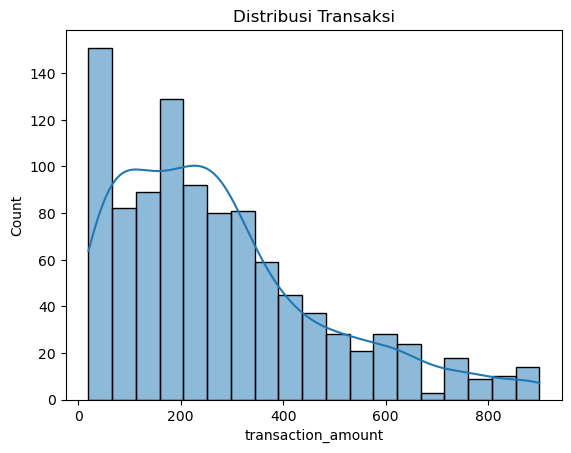

In [9]:
#data exploration 8a, mengecek distribusi data transaction_amount dengan tampilan histplot untuk grafik distribusinya.
sns.histplot(data_ff['transaction_amount'],kde=True)
plt.title('Distribusi Transaksi')
plt.show()

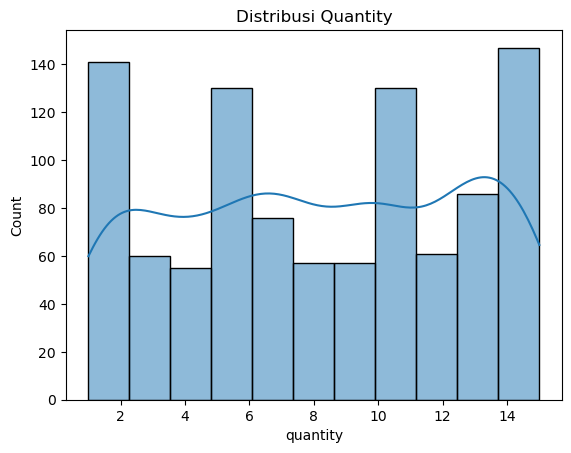

In [10]:
#data exploration 8b, mengecek distribusi data transaction_amount dengan tampilan histplot untuk grafik distribusinya.
sns.histplot(data_ff['quantity'],kde=True)
plt.title('Distribusi Quantity')
plt.show()

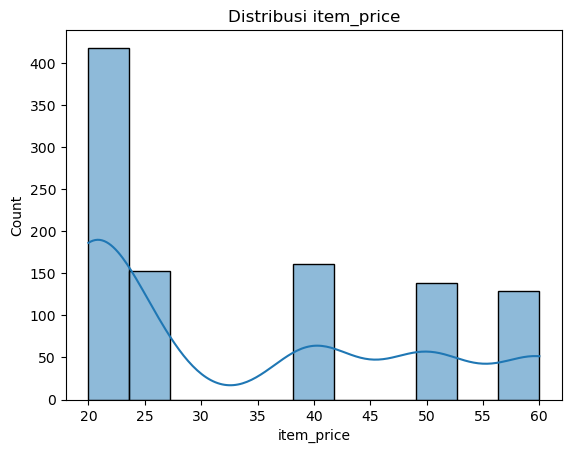

In [11]:
#data exploration 8c, mengecek distribusi data item_price dengan tampilan histplot untuk grafik distribusinya.
sns.histplot(data_ff['item_price'],kde=True)
plt.title('Distribusi item_price')
plt.show()

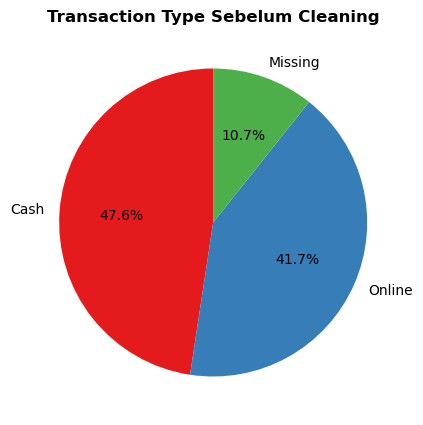

In [12]:
#data exploration 8d, pengecekan distribusi transacion type menggunakan pie chart (menggunakan value counts karena saya ingin melihat seberapa sering data tersebut muncul pada keseluruhan data)
plt.figure(figsize=(10,5))
temp = data_ff.copy()
temp['transaction_type']=temp['transaction_type'].fillna('Missing')
sebelum_diisi_isnull = temp['transaction_type'].value_counts()
plt.pie(sebelum_diisi_isnull, labels=sebelum_diisi_isnull.index, autopct='%1.1f%%', startangle=90,
               colors=sns.color_palette('Set1', len(sebelum_diisi_isnull)))
plt.title('Transaction Type Sebelum Cleaning', fontweight='bold')
plt.show()

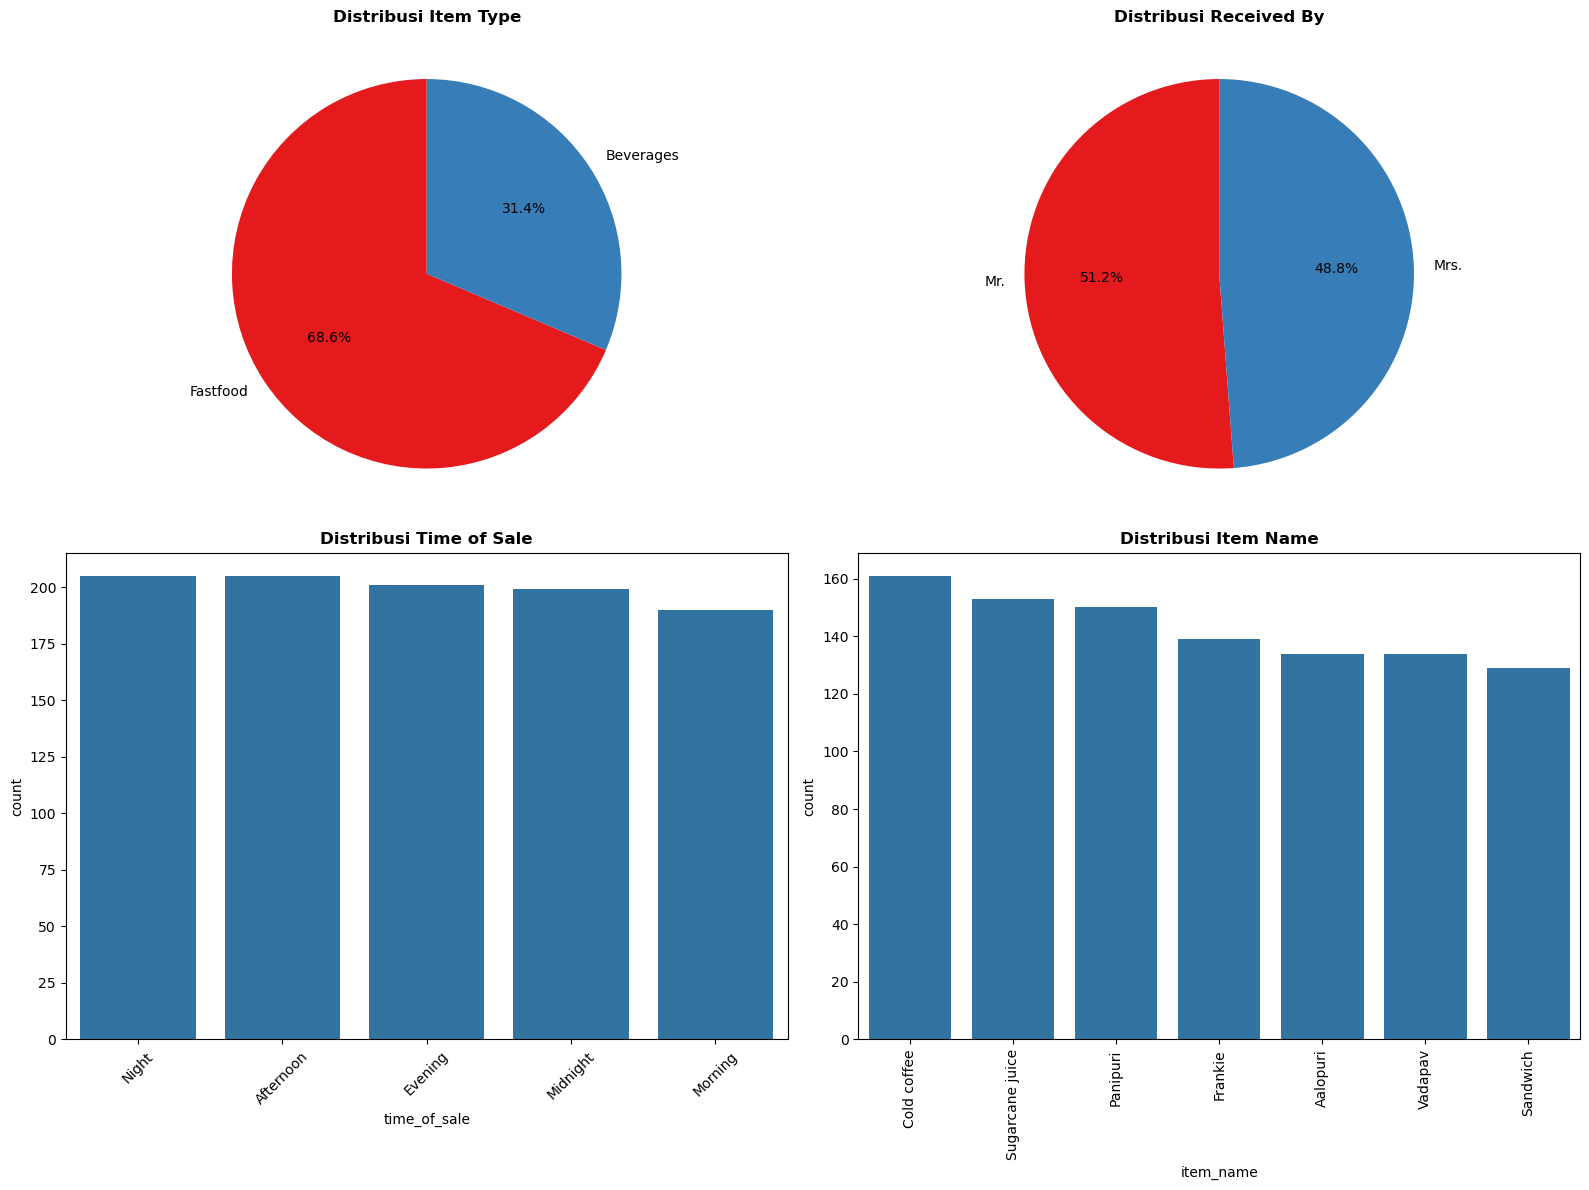

In [13]:
#data exploration 8e, menampilkan seluruh distribusi data object yang ada menggunakan pie chart dan bar chart (alasan menggunakan value counts masih sama dengan alasan pada transaction amount)
fig, axes = plt.subplots(2, 2, figsize=(16,12))

# PIE CHART - item type
item_type_dist = data_ff['item_type'] \
    .fillna('Missing') \
    .value_counts()

axes[0,0].pie(
    item_type_dist,
    labels=item_type_dist.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set1', len(item_type_dist))
)

axes[0,0].set_title(
    'Distribusi Item Type',
    fontweight='bold'
)

# PIE CHART - received by
received_by_dist = data_ff['received_by'] \
    .fillna('Missing') \
    .value_counts()

axes[0,1].pie(
    received_by_dist,
    labels=received_by_dist.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set1', len(received_by_dist))
)

axes[0,1].set_title(
    'Distribusi Received By',
    fontweight='bold'
)

# BAR CHART - time of sale
sns.countplot(
    data=data_ff,
    x='time_of_sale',
    order=data_ff['time_of_sale'].value_counts().index,
    ax=axes[1,0]
)

axes[1,0].set_title(
    'Distribusi Time of Sale',
    fontweight='bold'
)

axes[1,0].tick_params(axis='x', rotation=45)

# BAR CHART - item name

sns.countplot(
    data=data_ff,
    x='item_name',
    order=data_ff['item_name'].value_counts().index,
    ax=axes[1,1]
)

axes[1,1].set_title(
    'Distribusi Item Name',
    fontweight='bold'
)

axes[1,1].tick_params(axis='x', rotation=90)

plt.tight_layout()

plt.show()

In [14]:
#data exploration 9, fungsi isnull() dan sum() saya gunakan untuk menghitung/count jumlah missing data yang ada. Ternyata terdapat missing value yang ada pada transaction type.
missing = data_ff.isnull().sum()
missing_percentage = (missing / len(data_ff)*100).round(2)
missing_data_ff = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_percentage})
print("Missing Value")
print(missing_data_ff[missing_data_ff['Jumlah Missing'] > 0])

Missing Value
                  Jumlah Missing  Persentase (%)
transaction_type             107            10.7


In [15]:
#data exploration 10, melakukan pengecekan ulang apakah ada dulicated pada data yang dimiliki
data_ff_duplicated= data_ff.duplicated().sum()
print("Jumlah data yang duplikat:", data_ff_duplicated)

Jumlah data yang duplikat: 0


<Axes: >

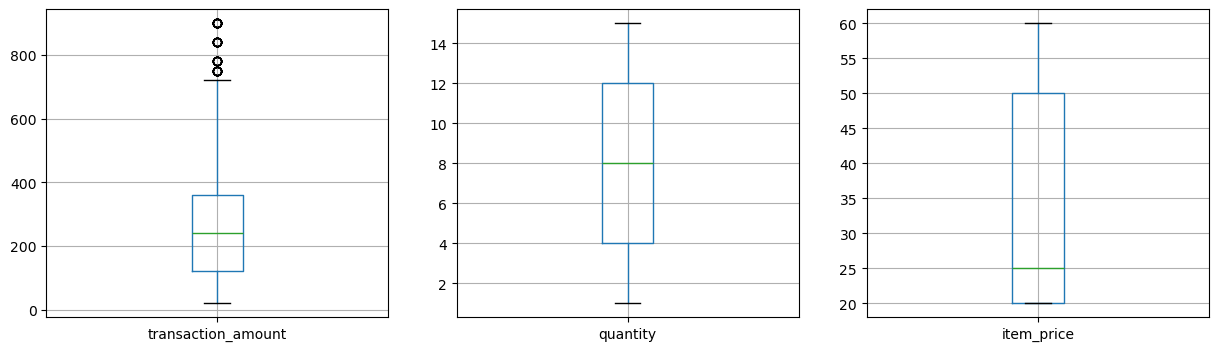

In [16]:
#data exploration 11, melakukan pengecekan outlier dari data numeric melalui check visualisasi boxplot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
data_ff.boxplot(column='transaction_amount', ax=axes[0])
data_ff.boxplot(column='quantity', ax=axes[1])
data_ff.boxplot(column='item_price', ax=axes[2])

Dari hasil pengecekan visualisasi melalui boxplot, hanya kolom transaction amount yang memiliki outlier pada datanya

In [17]:
#data exploration 12, melakukan pengecekan outlier dengan metode iqr pada kolom quantity
#deteksi outlier quantity menggunakan iqr
Q1 = data_ff["quantity"].quantile(0.25)
Q3 = data_ff["quantity"].quantile(0.75)
IQR = Q3-Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outlier_quantity_iqr = data_ff[(data_ff["quantity"]<lower)|(data_ff["quantity"]>upper)]
outlier_quantity_iqr

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale


Tidak ditemukannya outlier pada kolom quantity setelah melakukan pengecekan menggunakan iqr dan visual

In [18]:
#data exploration 13, melakukan pengecekan outlier dengan metode iqr pada kolom item_price
#deteksi outlier item_price menggunakan iqr
Q1 = data_ff["item_price"].quantile(0.25)
Q3 = data_ff["item_price"].quantile(0.75)
IQR = Q3-Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outlier_item_price_iqr = data_ff[(data_ff["item_price"]<lower)|(data_ff["item_price"]>upper)]
outlier_item_price_iqr

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale


Tidak ditemukannya outlier pada kolom item_price setelah melakukan pengecekan menggunakan iqr dan visual

In [19]:
#data exploration 14, melakukan pengecekan outlier dengan metode iqr pada kolom transaction_amount
#deteksi outlier transaction_amount menggunakan iqr
Q1 = data_ff["transaction_amount"].quantile(0.25)
Q3 = data_ff["transaction_amount"].quantile(0.75)
IQR = Q3-Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outlier_transaction_amount_iqr = data_ff[(data_ff["transaction_amount"]<lower)|(data_ff["transaction_amount"]>upper)]
outlier_transaction_amount_iqr

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
47,48,2/23/2023,Sandwich,Fastfood,60,14,840,Online,Mr.,Afternoon
50,51,5/16/2022,Frankie,Fastfood,50,15,750,Online,Mrs.,Morning
95,96,8/22/2022,Sandwich,Fastfood,60,15,900,NaN,Mr.,Morning
137,138,09-01-2022,Sandwich,Fastfood,60,15,900,Online,Mr.,Night
144,145,10-09-2022,Sandwich,Fastfood,60,14,840,Online,Mr.,Morning
147,148,3/19/2023,Sandwich,Fastfood,60,13,780,Online,Mr.,Evening
197,198,01-05-2023,Frankie,Fastfood,50,15,750,Cash,Mr.,Morning
269,270,09-07-2022,Sandwich,Fastfood,60,13,780,Cash,Mr.,Evening
307,308,12/17/2022,Sandwich,Fastfood,60,13,780,Online,Mr.,Evening
318,319,6/30/2022,Frankie,Fastfood,50,15,750,Cash,Mr.,Afternoon


In [20]:
print(upper)

720.0


In [21]:
#data cleaning 14a, melihat persentase outlier untuk menentukan apa tindakan berikutnya
jumlah_outlier = len(outlier_transaction_amount_iqr)
print(f"jumlah outlier: {jumlah_outlier}")

#kalkulasi outlier dianggap aman
kalkulasi_outlier_transac = (jumlah_outlier/1000)*100
if (jumlah_outlier/1000)*100<5:
    print(f"persentase outlier_transaction:{kalkulasi_outlier_transac}%","Aman")

else:
    print(f"persentase outlier_transaction:{kalkulasi_outlier_transac}%","Tdk-Aman")

jumlah outlier: 44
persentase outlier_transaction:4.3999999999999995% Aman


Terdapat Outlier pada kolom transaction amount sebesar 4,39% dari 100% data. Alasan saya tidak menangani oulier ialah karena outlier yang terjadi bukanlah kesalahan input atau error pengukuran melainkan memang nilai eksrim di dunia nyata, yang mana pada kasus transaction amount ini ada pembeli yang melakukan pembelian dalam jumlah besar maka dari itu ada terjadinya data-data outlier tersebut.

##### Data Exploration Results
Data issue yang dimiliki:
1. Pada Kolum data yang dimiliki masih banyak data yang memiliki type data yang tidak sesuai terutama yang berbentuk object.
2. Data numerik yang dimiliki pada data memiliki distribusi yang tidak normal berdasarkan visualisasi grafik.
3. Terdapat missing value sebesar 10.7% dari keseluruhan data.
4. Terdapat outlier sebesar 4.39% data pada kolum transaction amount.

### Data Cleaning

In [22]:
#data cleaning 1, saya menggunakan unique() untuk menampilkan atribut apa saja yang dimiliki. dari unique juga saya dapat melihat apakah ada missing value, inkonsisten data, dan juga duplicate
for col in data_ff.columns:
    print(f"\nkolom:{col}")
    print(data_ff[col].unique())


kolom:order_id
[   1    2    3    4    5    6    7    8    9   10   11   12   13   14
   15   16   17   18   19   20   21   22   23   24   25   26   27   28
   29   30   31   32   33   34   35   36   37   38   39   40   41   42
   43   44   45   46   47   48   49   50   51   52   53   54   55   56
   57   58   59   60   61   62   63   64   65   66   67   68   69   70
   71   72   73   74   75   76   77   78   79   80   81   82   83   84
   85   86   87   88   89   90   91   92   93   94   95   96   97   98
   99  100  101  102  103  104  105  106  107  108  109  110  111  112
  113  114  115  116  117  118  119  120  121  122  123  124  125  126
  127  128  129  130  131  132  133  134  135  136  137  138  139  140
  141  142  143  144  145  146  147  148  149  150  151  152  153  154
  155  156  157  158  159  160  161  162  163  164  165  166  167  168
  169  170  171  172  173  174  175  176  177  178  179  180  181  182
  183  184  185  186  187  188  189  190  191  192  193  194 

In [23]:
#data cleaning 2, melakukan pengecekan ulang apakah ada dulicated pada data yang dimiliki
data_ff.duplicated().sum()

np.int64(0)

In [24]:
#data cleaning 3, cleaning missing value pada transaction type
#mengcopy data terlebih dahulu agar data asli tidak terganti
dataclean = data_ff.copy()
print(dataclean)

     order_id        date        item_name  item_type  item_price  quantity  \
0           1  07-03-2022         Aalopuri   Fastfood          20        13   
1           2   8/23/2022          Vadapav   Fastfood          20        15   
2           3  11/20/2022          Vadapav   Fastfood          20         1   
3           4  02-03-2023  Sugarcane juice  Beverages          25         6   
4           5  10-02-2022  Sugarcane juice  Beverages          25         8   
..        ...         ...              ...        ...         ...       ...   
995       996   3/19/2023          Frankie   Fastfood          50        10   
996       997   9/20/2022         Sandwich   Fastfood          60         7   
997       998   1/26/2023         Sandwich   Fastfood          60        13   
998       999   8/27/2022         Panipuri   Fastfood          20         5   
999      1000   5/29/2022         Aalopuri   Fastfood          20         3   

     transaction_amount transaction_type received_b

In [25]:
#data cleaning 4, menghitung jumlah dari setiap atribut yang ada pada transaction type dengan value_counts()
dataclean['transaction_type'].value_counts()

transaction_type
Cash      476
Online    417
Name: count, dtype: int64

In [26]:
#data cleaning 5, mengisi missing value pada transaction_type
#memanggil fungsi random seed terlebih dahulu, karena saya akan mengisi missing value dengan inputan random yang akan saya buat
np.random.seed(42)   #42 pada dalam tutup kurung tidak memiliki makna itu hanya kebiasaan programmer yang mengartikan 42 itu semesta

# menghitung total data yang tidak missing terlebih dahulu
total = 476 + 417  # 476 merupakan jumlah yang cash dan 417 merupakan jumlah yang online

#membuat inputan yang akan dimasukkan ke missing value
isi = dataclean['transaction_type'].isin([])|dataclean['transaction_type'].isnull()

#mengisi missing value dengan inputan isi yang sudah kita buat
dataclean.loc[isi,'transaction_type']=np.random.choice(
    ['Cash','Online'],
    size=isi.sum(),
    p=[476/total, 417/total]
)
dataclean['transaction_type']

0        Cash
1        Cash
2        Cash
3      Online
4      Online
        ...  
995      Cash
996    Online
997      Cash
998      Cash
999    Online
Name: transaction_type, Length: 1000, dtype: object

In [27]:
#data clean 6, memastikan apakah jumlah dari cash dan online sudah berubah

print(dataclean['transaction_type'].value_counts())
print(dataclean.head(5))
dataclean.tail(5)

transaction_type
Cash      538
Online    462
Name: count, dtype: int64
   order_id        date        item_name  item_type  item_price  quantity  \
0         1  07-03-2022         Aalopuri   Fastfood          20        13   
1         2   8/23/2022          Vadapav   Fastfood          20        15   
2         3  11/20/2022          Vadapav   Fastfood          20         1   
3         4  02-03-2023  Sugarcane juice  Beverages          25         6   
4         5  10-02-2022  Sugarcane juice  Beverages          25         8   

   transaction_amount transaction_type received_by time_of_sale  
0                 260             Cash         Mr.        Night  
1                 300             Cash         Mr.    Afternoon  
2                  20             Cash         Mr.    Afternoon  
3                 150           Online         Mr.        Night  
4                 200           Online         Mr.      Evening  


,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
995,996,3/19/2023,Frankie,Fastfood,50,10,500,Cash,Mrs.,Evening
996,997,9/20/2022,Sandwich,Fastfood,60,7,420,Online,Mr.,Evening
997,998,1/26/2023,Sandwich,Fastfood,60,13,780,Cash,Mr.,Evening
998,999,8/27/2022,Panipuri,Fastfood,20,5,100,Cash,Mrs.,Afternoon
999,1000,5/29/2022,Aalopuri,Fastfood,20,3,60,Online,Mrs.,Midnight


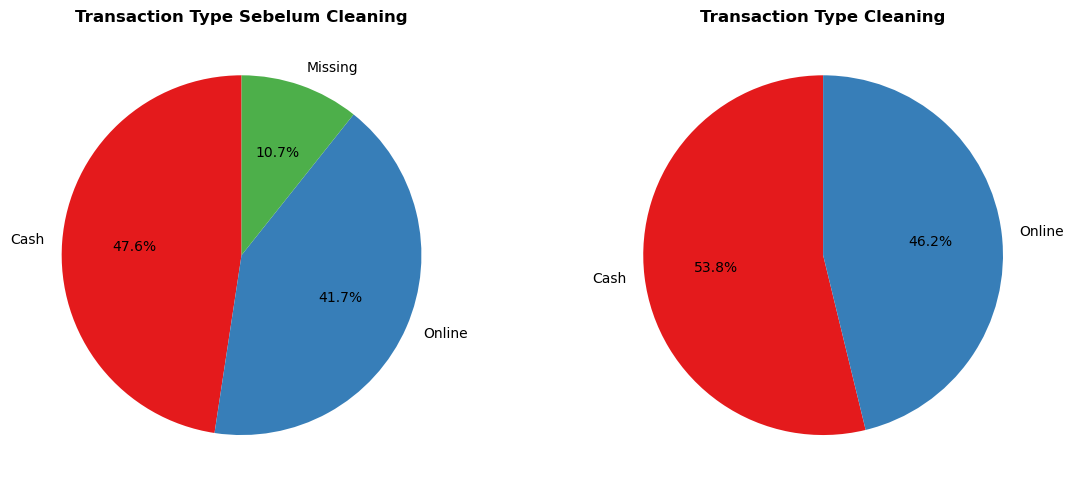

In [28]:
#pengecekan distribusi antara sesudah diisi data kosong dan sebelum diisi data kosong
fig, axes = plt.subplots(1, 2, figsize=(12,5))
#sebelum diisi
temp = data_ff.copy()
temp['transaction_type']=temp['transaction_type'].fillna('Missing')
sebelum_diisi_isnull = temp['transaction_type'].value_counts()
axes[0].pie(sebelum_diisi_isnull, labels=sebelum_diisi_isnull.index, autopct='%1.1f%%', startangle=90,
               colors=sns.color_palette('Set1', len(sebelum_diisi_isnull)))
axes[0].set_title('Transaction Type Sebelum Cleaning', fontweight='bold')
                     
#sesudah diisi dengan probability
sesudah_diisi_isnull = dataclean['transaction_type'].value_counts()
axes[1].pie(sesudah_diisi_isnull, labels=sesudah_diisi_isnull.index, autopct='%1.1f%%', startangle=90,
               colors=sns.color_palette('Set1', len(sesudah_diisi_isnull)))
axes[1].set_title('Transaction Type Cleaning', fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
#data clean 7, memastikan kembali jumlah missing value pada data yang sudah dibersihkan dengan isnull() dan sum()
dataclean.isnull().sum()

order_id              0
date                  0
item_name             0
item_type             0
item_price            0
quantity              0
transaction_amount    0
transaction_type      0
received_by           0
time_of_sale          0
dtype: int64

### Data Cleaning (bagian distribusi)

Pengecekkan apakah kolom quantity terdistribusi normal atau tidak,:
H0= Data kolom quantity berdistribusi normal,
H1= Data kolom quantity tidak berdistribusi normal.
Dengan Alpha yang digunakan ialah 0.05

In [30]:
#data cleaning distribusi 1, melakukan pengecekan distribusi normal dan uji normalitas
#1. uji normalitas data quantity
from scipy.stats import shapiro

for seg in dataclean['quantity'].unique():
    stat, p = shapiro(dataclean['quantity'])
    print(seg,"p-value:", p)
    if p> 0.05:
        print("Data terdistribusi normal")
    else:
        print("Data tidak terdistribusi normal")

13 p-value: 1.0344615736024162e-19
Data tidak terdistribusi normal
15 p-value: 1.0344615736024162e-19
Data tidak terdistribusi normal
1 p-value: 1.0344615736024162e-19
Data tidak terdistribusi normal
6 p-value: 1.0344615736024162e-19
Data tidak terdistribusi normal
8 p-value: 1.0344615736024162e-19
Data tidak terdistribusi normal
10 p-value: 1.0344615736024162e-19
Data tidak terdistribusi normal
9 p-value: 1.0344615736024162e-19
Data tidak terdistribusi normal
14 p-value: 1.0344615736024162e-19
Data tidak terdistribusi normal
5 p-value: 1.0344615736024162e-19
Data tidak terdistribusi normal
4 p-value: 1.0344615736024162e-19
Data tidak terdistribusi normal
3 p-value: 1.0344615736024162e-19
Data tidak terdistribusi normal
11 p-value: 1.0344615736024162e-19
Data tidak terdistribusi normal
12 p-value: 1.0344615736024162e-19
Data tidak terdistribusi normal
2 p-value: 1.0344615736024162e-19
Data tidak terdistribusi normal
7 p-value: 1.0344615736024162e-19
Data tidak terdistribusi normal


In [31]:
#2. transformasi data quantity ke log1p
dataclean['log_quantity']= np.log1p(dataclean['quantity'])
dataclean

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale,log_quantity
0,1,07-03-2022,Aalopuri,Fastfood,20,13,260,Cash,Mr.,Night,2.639057
1,2,8/23/2022,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon,2.772589
2,3,11/20/2022,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon,0.693147
3,4,02-03-2023,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night,1.945910
4,5,10-02-2022,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening,2.197225
...,...,...,...,...,...,...,...,...,...,...,...
995,996,3/19/2023,Frankie,Fastfood,50,10,500,Cash,Mrs.,Evening,2.397895
996,997,9/20/2022,Sandwich,Fastfood,60,7,420,Online,Mr.,Evening,2.079442
997,998,1/26/2023,Sandwich,Fastfood,60,13,780,Cash,Mr.,Evening,2.639057
998,999,8/27/2022,Panipuri,Fastfood,20,5,100,Cash,Mrs.,Afternoon,1.791759


In [32]:
#3.uji normalitas lagi menggunakan data log_quantity
from scipy.stats import shapiro

for seg in dataclean['log_quantity'].unique():
    stat, p = shapiro(dataclean['log_quantity'])
    print(seg,"p-value:", p)
    if p> 0.05:
        print("Data terdistribusi normal")
    else:
        print("Data tidak terdistribusi normal")

2.6390573296152584 p-value: 1.102549169124671e-25
Data tidak terdistribusi normal
2.772588722239781 p-value: 1.102549169124671e-25
Data tidak terdistribusi normal
0.6931471805599453 p-value: 1.102549169124671e-25
Data tidak terdistribusi normal
1.9459101490553132 p-value: 1.102549169124671e-25
Data tidak terdistribusi normal
2.1972245773362196 p-value: 1.102549169124671e-25
Data tidak terdistribusi normal
2.3978952727983707 p-value: 1.102549169124671e-25
Data tidak terdistribusi normal
2.302585092994046 p-value: 1.102549169124671e-25
Data tidak terdistribusi normal
2.70805020110221 p-value: 1.102549169124671e-25
Data tidak terdistribusi normal
1.791759469228055 p-value: 1.102549169124671e-25
Data tidak terdistribusi normal
1.6094379124341003 p-value: 1.102549169124671e-25
Data tidak terdistribusi normal
1.3862943611198906 p-value: 1.102549169124671e-25
Data tidak terdistribusi normal
2.4849066497880004 p-value: 1.102549169124671e-25
Data tidak terdistribusi normal
2.5649493574615367 p-

In [33]:
#4,transformasi data quantity lagi ke sqrt
dataclean['sqrt_quantity']= np.sqrt(dataclean['quantity'])
dataclean

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale,log_quantity,sqrt_quantity
0,1,07-03-2022,Aalopuri,Fastfood,20,13,260,Cash,Mr.,Night,2.639057,3.605551
1,2,8/23/2022,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon,2.772589,3.872983
2,3,11/20/2022,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon,0.693147,1.000000
3,4,02-03-2023,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night,1.945910,2.449490
4,5,10-02-2022,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening,2.197225,2.828427
...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,3/19/2023,Frankie,Fastfood,50,10,500,Cash,Mrs.,Evening,2.397895,3.162278
996,997,9/20/2022,Sandwich,Fastfood,60,7,420,Online,Mr.,Evening,2.079442,2.645751
997,998,1/26/2023,Sandwich,Fastfood,60,13,780,Cash,Mr.,Evening,2.639057,3.605551
998,999,8/27/2022,Panipuri,Fastfood,20,5,100,Cash,Mrs.,Afternoon,1.791759,2.236068


In [34]:
#5.uji normalitas lagi menggunakan data sqrt_quantity
from scipy.stats import shapiro

for seg in dataclean['quantity'].unique():
    stat, p = shapiro(dataclean['sqrt_quantity'])
    print(seg,"p-value:", p)
    if p> 0.05:
        print("Data terdistribusi normal")
    else:
        print("Data tidak terdistribusi normal")

13 p-value: 1.751975932760457e-21
Data tidak terdistribusi normal
15 p-value: 1.751975932760457e-21
Data tidak terdistribusi normal
1 p-value: 1.751975932760457e-21
Data tidak terdistribusi normal
6 p-value: 1.751975932760457e-21
Data tidak terdistribusi normal
8 p-value: 1.751975932760457e-21
Data tidak terdistribusi normal
10 p-value: 1.751975932760457e-21
Data tidak terdistribusi normal
9 p-value: 1.751975932760457e-21
Data tidak terdistribusi normal
14 p-value: 1.751975932760457e-21
Data tidak terdistribusi normal
5 p-value: 1.751975932760457e-21
Data tidak terdistribusi normal
4 p-value: 1.751975932760457e-21
Data tidak terdistribusi normal
3 p-value: 1.751975932760457e-21
Data tidak terdistribusi normal
11 p-value: 1.751975932760457e-21
Data tidak terdistribusi normal
12 p-value: 1.751975932760457e-21
Data tidak terdistribusi normal
2 p-value: 1.751975932760457e-21
Data tidak terdistribusi normal
7 p-value: 1.751975932760457e-21
Data tidak terdistribusi normal


In [35]:
#6, transformasi data quantity ke boxcox
dataclean['boxcox_quantity'],lam= stats.boxcox(dataclean['quantity'])
print("lambda:", lam)
dataclean

lambda: 0.7531115752467614


,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale,log_quantity,sqrt_quantity,boxcox_quantity
0,1,07-03-2022,Aalopuri,Fastfood,20,13,260,Cash,Mr.,Night,2.639057,3.605551,7.835737
1,2,8/23/2022,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon,2.772589,3.872983,8.878482
2,3,11/20/2022,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon,0.693147,1.000000,0.000000
3,4,02-03-2023,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night,1.945910,2.449490,3.791061
4,5,10-02-2022,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening,2.197225,2.828427,5.029410
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,3/19/2023,Frankie,Fastfood,50,10,500,Cash,Mrs.,Evening,2.397895,3.162278,6.192771
996,997,9/20/2022,Sandwich,Fastfood,60,7,420,Online,Mr.,Evening,2.079442,2.645751,4.421195
997,998,1/26/2023,Sandwich,Fastfood,60,13,780,Cash,Mr.,Evening,2.639057,3.605551,7.835737
998,999,8/27/2022,Panipuri,Fastfood,20,5,100,Cash,Mrs.,Afternoon,1.791759,2.236068,3.134314


In [36]:
#7,uji normalitas lagi menggunakan data boxcox_quantity
from scipy.stats import shapiro

for seg in dataclean['quantity'].unique():
    stat, p = shapiro(dataclean['boxcox_quantity'])
    print(seg,"p-value:", p)
    if p> 0.05:
        print("Data terdistribusi normal")
    else:
        print("Data tidak terdistribusi normal")

13 p-value: 7.773634194298733e-20
Data tidak terdistribusi normal
15 p-value: 7.773634194298733e-20
Data tidak terdistribusi normal
1 p-value: 7.773634194298733e-20
Data tidak terdistribusi normal
6 p-value: 7.773634194298733e-20
Data tidak terdistribusi normal
8 p-value: 7.773634194298733e-20
Data tidak terdistribusi normal
10 p-value: 7.773634194298733e-20
Data tidak terdistribusi normal
9 p-value: 7.773634194298733e-20
Data tidak terdistribusi normal
14 p-value: 7.773634194298733e-20
Data tidak terdistribusi normal
5 p-value: 7.773634194298733e-20
Data tidak terdistribusi normal
4 p-value: 7.773634194298733e-20
Data tidak terdistribusi normal
3 p-value: 7.773634194298733e-20
Data tidak terdistribusi normal
11 p-value: 7.773634194298733e-20
Data tidak terdistribusi normal
12 p-value: 7.773634194298733e-20
Data tidak terdistribusi normal
2 p-value: 7.773634194298733e-20
Data tidak terdistribusi normal
7 p-value: 7.773634194298733e-20
Data tidak terdistribusi normal


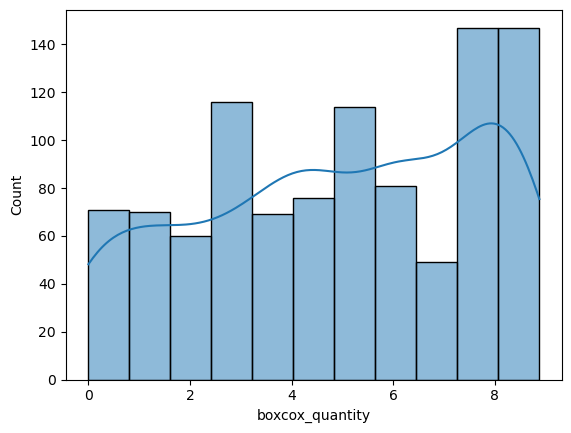

In [37]:
#8. menampilkan distribusi quantity pada hasil boxcox
sns.histplot(dataclean['boxcox_quantity'], kde = True)
plt.show()

In [38]:
#9,melakukan uji normalitas pada data item_price

In [39]:
from scipy.stats import shapiro

for seg in dataclean['item_price'].unique():
    stat, p = shapiro(dataclean['item_price'])
    print(seg,"p-value:", p)
    if p> 0.05:
        print("Data terdistribusi normal")
    else:
        print("Data tidak terdistribusi normal")

20 p-value: 3.94447376786261e-34
Data tidak terdistribusi normal
25 p-value: 3.94447376786261e-34
Data tidak terdistribusi normal
50 p-value: 3.94447376786261e-34
Data tidak terdistribusi normal
60 p-value: 3.94447376786261e-34
Data tidak terdistribusi normal
40 p-value: 3.94447376786261e-34
Data tidak terdistribusi normal


In [40]:
#10, melakukan transformasi ke bentuk log1p pada data item_price
dataclean['log_itemp']= np.log1p(dataclean['item_price'])
dataclean

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale,log_quantity,sqrt_quantity,boxcox_quantity,log_itemp
0,1,07-03-2022,Aalopuri,Fastfood,20,13,260,Cash,Mr.,Night,2.639057,3.605551,7.835737,3.044522
1,2,8/23/2022,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon,2.772589,3.872983,8.878482,3.044522
2,3,11/20/2022,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon,0.693147,1.000000,0.000000,3.044522
3,4,02-03-2023,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night,1.945910,2.449490,3.791061,3.258097
4,5,10-02-2022,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening,2.197225,2.828427,5.029410,3.258097
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,3/19/2023,Frankie,Fastfood,50,10,500,Cash,Mrs.,Evening,2.397895,3.162278,6.192771,3.931826
996,997,9/20/2022,Sandwich,Fastfood,60,7,420,Online,Mr.,Evening,2.079442,2.645751,4.421195,4.110874
997,998,1/26/2023,Sandwich,Fastfood,60,13,780,Cash,Mr.,Evening,2.639057,3.605551,7.835737,4.110874
998,999,8/27/2022,Panipuri,Fastfood,20,5,100,Cash,Mrs.,Afternoon,1.791759,2.236068,3.134314,3.044522


In [41]:
#11.uji normalitas lagi menggunakan data log_itemp
from scipy.stats import shapiro

for seg in dataclean['item_price'].unique():
    stat, p = shapiro(dataclean['log_itemp'])
    print(seg,"p-value:", p)
    if p> 0.05:
        print("Data terdistribusi normal")
    else:
        print("Data tidak terdistribusi normal")

20 p-value: 9.025399360811748e-34
Data tidak terdistribusi normal
25 p-value: 9.025399360811748e-34
Data tidak terdistribusi normal
50 p-value: 9.025399360811748e-34
Data tidak terdistribusi normal
60 p-value: 9.025399360811748e-34
Data tidak terdistribusi normal
40 p-value: 9.025399360811748e-34
Data tidak terdistribusi normal


In [42]:
#12,transformasi data item_price lagi ke sqrt
dataclean['sqrt_itemp']= np.sqrt(dataclean['item_price'])
dataclean

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale,log_quantity,sqrt_quantity,boxcox_quantity,log_itemp,sqrt_itemp
0,1,07-03-2022,Aalopuri,Fastfood,20,13,260,Cash,Mr.,Night,2.639057,3.605551,7.835737,3.044522,4.472136
1,2,8/23/2022,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon,2.772589,3.872983,8.878482,3.044522,4.472136
2,3,11/20/2022,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon,0.693147,1.000000,0.000000,3.044522,4.472136
3,4,02-03-2023,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night,1.945910,2.449490,3.791061,3.258097,5.000000
4,5,10-02-2022,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening,2.197225,2.828427,5.029410,3.258097,5.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,3/19/2023,Frankie,Fastfood,50,10,500,Cash,Mrs.,Evening,2.397895,3.162278,6.192771,3.931826,7.071068
996,997,9/20/2022,Sandwich,Fastfood,60,7,420,Online,Mr.,Evening,2.079442,2.645751,4.421195,4.110874,7.745967
997,998,1/26/2023,Sandwich,Fastfood,60,13,780,Cash,Mr.,Evening,2.639057,3.605551,7.835737,4.110874,7.745967
998,999,8/27/2022,Panipuri,Fastfood,20,5,100,Cash,Mrs.,Afternoon,1.791759,2.236068,3.134314,3.044522,4.472136


In [43]:
#13.uji normalitas lagi menggunakan data sqrt_quantity
from scipy.stats import shapiro

for seg in dataclean['item_price'].unique():
    stat, p = shapiro(dataclean['sqrt_itemp'])
    print(seg,"p-value:", p)
    if p> 0.05:
        print("Data terdistribusi normal")
    else:
        print("Data tidak terdistribusi normal")

20 p-value: 8.126605100446095e-34
Data tidak terdistribusi normal
25 p-value: 8.126605100446095e-34
Data tidak terdistribusi normal
50 p-value: 8.126605100446095e-34
Data tidak terdistribusi normal
60 p-value: 8.126605100446095e-34
Data tidak terdistribusi normal
40 p-value: 8.126605100446095e-34
Data tidak terdistribusi normal


In [44]:
#14 transformasi data item_price ke boxcox
dataclean['boxcox_itemp'],lam= stats.boxcox(dataclean['item_price'])
print("lambda:", lam)
dataclean

lambda: -0.9017839995579744


,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale,log_quantity,sqrt_quantity,boxcox_quantity,log_itemp,sqrt_itemp,boxcox_itemp
0,1,07-03-2022,Aalopuri,Fastfood,20,13,260,Cash,Mr.,Night,2.639057,3.605551,7.835737,3.044522,4.472136,1.034500
1,2,8/23/2022,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon,2.772589,3.872983,8.878482,3.044522,4.472136,1.034500
2,3,11/20/2022,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon,0.693147,1.000000,0.000000,3.044522,4.472136,1.034500
3,4,02-03-2023,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night,1.945910,2.449490,3.791061,3.258097,5.000000,1.048063
4,5,10-02-2022,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening,2.197225,2.828427,5.029410,3.258097,5.000000,1.048063
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,3/19/2023,Frankie,Fastfood,50,10,500,Cash,Mrs.,Evening,2.397895,3.162278,6.192771,3.931826,7.071068,1.076345
996,997,9/20/2022,Sandwich,Fastfood,60,7,420,Online,Mr.,Evening,2.079442,2.645751,4.421195,4.110874,7.745967,1.081282
997,998,1/26/2023,Sandwich,Fastfood,60,13,780,Cash,Mr.,Evening,2.639057,3.605551,7.835737,4.110874,7.745967,1.081282
998,999,8/27/2022,Panipuri,Fastfood,20,5,100,Cash,Mrs.,Afternoon,1.791759,2.236068,3.134314,3.044522,4.472136,1.034500


In [45]:
#15.uji normalitas lagi menggunakan data boxcox_itemp
from scipy.stats import shapiro

for seg in dataclean['item_price'].unique():
    stat, p = shapiro(dataclean['boxcox_itemp'])
    print(seg,"p-value:", p)
    if p> 0.05:
        print("Data terdistribusi normal")
    else:
        print("Data tidak terdistribusi normal")

20 p-value: 3.3604543326183315e-34
Data tidak terdistribusi normal
25 p-value: 3.3604543326183315e-34
Data tidak terdistribusi normal
50 p-value: 3.3604543326183315e-34
Data tidak terdistribusi normal
60 p-value: 3.3604543326183315e-34
Data tidak terdistribusi normal
40 p-value: 3.3604543326183315e-34
Data tidak terdistribusi normal


In [46]:
#16, melakukan pengecekan distribusi normal pada data transaction amount
#1. transaction_amount terhadap item_name
for seg in dataclean['transaction_amount'].unique():
    stat, p = shapiro(dataclean['transaction_amount'])
    print(seg,"p-value:", p)
    if p> 0.05:
        print("Data terdistribusi normal")
    else:
        print("Data tidak terdistribusi normal")

260 p-value: 5.4820844710665364e-24
Data tidak terdistribusi normal
300 p-value: 5.4820844710665364e-24
Data tidak terdistribusi normal
20 p-value: 5.4820844710665364e-24
Data tidak terdistribusi normal
150 p-value: 5.4820844710665364e-24
Data tidak terdistribusi normal
200 p-value: 5.4820844710665364e-24
Data tidak terdistribusi normal
225 p-value: 5.4820844710665364e-24
Data tidak terdistribusi normal
280 p-value: 5.4820844710665364e-24
Data tidak terdistribusi normal
100 p-value: 5.4820844710665364e-24
Data tidak terdistribusi normal
400 p-value: 5.4820844710665364e-24
Data tidak terdistribusi normal
160 p-value: 5.4820844710665364e-24
Data tidak terdistribusi normal
180 p-value: 5.4820844710665364e-24
Data tidak terdistribusi normal
60 p-value: 5.4820844710665364e-24
Data tidak terdistribusi normal
660 p-value: 5.4820844710665364e-24
Data tidak terdistribusi normal
220 p-value: 5.4820844710665364e-24
Data tidak terdistribusi normal
600 p-value: 5.4820844710665364e-24
Data tidak ter

In [47]:
#17. transformasi data transaction amount ke log1p
dataclean['log_transac']= np.log1p(dataclean['transaction_amount'])
dataclean

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale,log_quantity,sqrt_quantity,boxcox_quantity,log_itemp,sqrt_itemp,boxcox_itemp,log_transac
0,1,07-03-2022,Aalopuri,Fastfood,20,13,260,Cash,Mr.,Night,2.639057,3.605551,7.835737,3.044522,4.472136,1.034500,5.564520
1,2,8/23/2022,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon,2.772589,3.872983,8.878482,3.044522,4.472136,1.034500,5.707110
2,3,11/20/2022,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon,0.693147,1.000000,0.000000,3.044522,4.472136,1.034500,3.044522
3,4,02-03-2023,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night,1.945910,2.449490,3.791061,3.258097,5.000000,1.048063,5.017280
4,5,10-02-2022,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening,2.197225,2.828427,5.029410,3.258097,5.000000,1.048063,5.303305
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,3/19/2023,Frankie,Fastfood,50,10,500,Cash,Mrs.,Evening,2.397895,3.162278,6.192771,3.931826,7.071068,1.076345,6.216606
996,997,9/20/2022,Sandwich,Fastfood,60,7,420,Online,Mr.,Evening,2.079442,2.645751,4.421195,4.110874,7.745967,1.081282,6.042633
997,998,1/26/2023,Sandwich,Fastfood,60,13,780,Cash,Mr.,Evening,2.639057,3.605551,7.835737,4.110874,7.745967,1.081282,6.660575
998,999,8/27/2022,Panipuri,Fastfood,20,5,100,Cash,Mrs.,Afternoon,1.791759,2.236068,3.134314,3.044522,4.472136,1.034500,4.615121


In [48]:
#18.uji normalitas lagi menggunakan data log_transac
from scipy.stats import shapiro

for seg in dataclean['transaction_amount'].unique():
    stat, p = shapiro(dataclean['log_transac'])
    print(seg,"p-value:", p)
    if p> 0.05:
        print("Data terdistribusi normal")
    else:
        print("Data tidak terdistribusi normal")

260 p-value: 2.480957322555273e-17
Data tidak terdistribusi normal
300 p-value: 2.480957322555273e-17
Data tidak terdistribusi normal
20 p-value: 2.480957322555273e-17
Data tidak terdistribusi normal
150 p-value: 2.480957322555273e-17
Data tidak terdistribusi normal
200 p-value: 2.480957322555273e-17
Data tidak terdistribusi normal
225 p-value: 2.480957322555273e-17
Data tidak terdistribusi normal
280 p-value: 2.480957322555273e-17
Data tidak terdistribusi normal
100 p-value: 2.480957322555273e-17
Data tidak terdistribusi normal
400 p-value: 2.480957322555273e-17
Data tidak terdistribusi normal
160 p-value: 2.480957322555273e-17
Data tidak terdistribusi normal
180 p-value: 2.480957322555273e-17
Data tidak terdistribusi normal
60 p-value: 2.480957322555273e-17
Data tidak terdistribusi normal
660 p-value: 2.480957322555273e-17
Data tidak terdistribusi normal
220 p-value: 2.480957322555273e-17
Data tidak terdistribusi normal
600 p-value: 2.480957322555273e-17
Data tidak terdistribusi norm

In [49]:
#19,transformasi data transaction amount lagi ke sqrt
dataclean['sqrt_transac']= np.sqrt(dataclean['transaction_amount'])
dataclean

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale,log_quantity,sqrt_quantity,boxcox_quantity,log_itemp,sqrt_itemp,boxcox_itemp,log_transac,sqrt_transac
0,1,07-03-2022,Aalopuri,Fastfood,20,13,260,Cash,Mr.,Night,2.639057,3.605551,7.835737,3.044522,4.472136,1.034500,5.564520,16.124515
1,2,8/23/2022,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon,2.772589,3.872983,8.878482,3.044522,4.472136,1.034500,5.707110,17.320508
2,3,11/20/2022,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon,0.693147,1.000000,0.000000,3.044522,4.472136,1.034500,3.044522,4.472136
3,4,02-03-2023,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night,1.945910,2.449490,3.791061,3.258097,5.000000,1.048063,5.017280,12.247449
4,5,10-02-2022,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening,2.197225,2.828427,5.029410,3.258097,5.000000,1.048063,5.303305,14.142136
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,3/19/2023,Frankie,Fastfood,50,10,500,Cash,Mrs.,Evening,2.397895,3.162278,6.192771,3.931826,7.071068,1.076345,6.216606,22.360680
996,997,9/20/2022,Sandwich,Fastfood,60,7,420,Online,Mr.,Evening,2.079442,2.645751,4.421195,4.110874,7.745967,1.081282,6.042633,20.493902
997,998,1/26/2023,Sandwich,Fastfood,60,13,780,Cash,Mr.,Evening,2.639057,3.605551,7.835737,4.110874,7.745967,1.081282,6.660575,27.928480
998,999,8/27/2022,Panipuri,Fastfood,20,5,100,Cash,Mrs.,Afternoon,1.791759,2.236068,3.134314,3.044522,4.472136,1.034500,4.615121,10.000000


In [50]:
#20.uji normalitas lagi menggunakan data log_transac
from scipy.stats import shapiro

for seg in dataclean['transaction_amount'].unique():
    stat, p = shapiro(dataclean['sqrt_transac'])
    print(seg,"p-value:", p)
    if p> 0.05:
        print("Data terdistribusi normal")
    else:
        print("Data tidak terdistribusi normal")

260 p-value: 2.2152314180141867e-10
Data tidak terdistribusi normal
300 p-value: 2.2152314180141867e-10
Data tidak terdistribusi normal
20 p-value: 2.2152314180141867e-10
Data tidak terdistribusi normal
150 p-value: 2.2152314180141867e-10
Data tidak terdistribusi normal
200 p-value: 2.2152314180141867e-10
Data tidak terdistribusi normal
225 p-value: 2.2152314180141867e-10
Data tidak terdistribusi normal
280 p-value: 2.2152314180141867e-10
Data tidak terdistribusi normal
100 p-value: 2.2152314180141867e-10
Data tidak terdistribusi normal
400 p-value: 2.2152314180141867e-10
Data tidak terdistribusi normal
160 p-value: 2.2152314180141867e-10
Data tidak terdistribusi normal
180 p-value: 2.2152314180141867e-10
Data tidak terdistribusi normal
60 p-value: 2.2152314180141867e-10
Data tidak terdistribusi normal
660 p-value: 2.2152314180141867e-10
Data tidak terdistribusi normal
220 p-value: 2.2152314180141867e-10
Data tidak terdistribusi normal
600 p-value: 2.2152314180141867e-10
Data tidak ter

In [51]:
#21, transformasi data quantity ke boxcox
dataclean['boxcox_transac'],lam= stats.boxcox(dataclean['transaction_amount'])
print("lambda:", lam)
dataclean

lambda: 0.32398390312044406


,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale,log_quantity,sqrt_quantity,boxcox_quantity,log_itemp,sqrt_itemp,boxcox_itemp,log_transac,sqrt_transac,boxcox_transac
0,1,07-03-2022,Aalopuri,Fastfood,20,13,260,Cash,Mr.,Night,2.639057,3.605551,7.835737,3.044522,4.472136,1.034500,5.564520,16.124515,15.615470
1,2,8/23/2022,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon,2.772589,3.872983,8.878482,3.044522,4.472136,1.034500,5.707110,17.320508,16.502955
2,3,11/20/2022,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon,0.693147,1.000000,0.000000,3.044522,4.472136,1.034500,3.044522,4.472136,5.060270
3,4,02-03-2023,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night,1.945910,2.449490,3.791061,3.258097,5.000000,1.048063,5.017280,12.247449,12.562734
4,5,10-02-2022,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening,2.197225,2.828427,5.029410,3.258097,5.000000,1.048063,5.303305,14.142136,14.091453
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,3/19/2023,Frankie,Fastfood,50,10,500,Cash,Mrs.,Evening,2.397895,3.162278,6.192771,3.931826,7.071068,1.076345,6.216606,22.360680,20.028720
996,997,9/20/2022,Sandwich,Fastfood,60,7,420,Online,Mr.,Evening,2.079442,2.645751,4.421195,4.110874,7.745967,1.081282,6.042633,20.493902,18.759185
997,998,1/26/2023,Sandwich,Fastfood,60,13,780,Cash,Mr.,Evening,2.639057,3.605551,7.835737,4.110874,7.745967,1.081282,6.660575,27.928480,23.610808
998,999,8/27/2022,Panipuri,Fastfood,20,5,100,Cash,Mrs.,Afternoon,1.791759,2.236068,3.134314,3.044522,4.472136,1.034500,4.615121,10.000000,10.636279


In [52]:
#22.uji normalitas lagi menggunakan data boxcox_transac
from scipy.stats import shapiro

for seg in dataclean['transaction_amount'].unique():
    stat, p = shapiro(dataclean['boxcox_transac'])
    print(seg,"p-value:", p)
    if p> 0.05:
        print("Data terdistribusi normal")
    else:
        print("Data tidak terdistribusi normal")

260 p-value: 8.380225436095653e-09
Data tidak terdistribusi normal
300 p-value: 8.380225436095653e-09
Data tidak terdistribusi normal
20 p-value: 8.380225436095653e-09
Data tidak terdistribusi normal
150 p-value: 8.380225436095653e-09
Data tidak terdistribusi normal
200 p-value: 8.380225436095653e-09
Data tidak terdistribusi normal
225 p-value: 8.380225436095653e-09
Data tidak terdistribusi normal
280 p-value: 8.380225436095653e-09
Data tidak terdistribusi normal
100 p-value: 8.380225436095653e-09
Data tidak terdistribusi normal
400 p-value: 8.380225436095653e-09
Data tidak terdistribusi normal
160 p-value: 8.380225436095653e-09
Data tidak terdistribusi normal
180 p-value: 8.380225436095653e-09
Data tidak terdistribusi normal
60 p-value: 8.380225436095653e-09
Data tidak terdistribusi normal
660 p-value: 8.380225436095653e-09
Data tidak terdistribusi normal
220 p-value: 8.380225436095653e-09
Data tidak terdistribusi normal
600 p-value: 8.380225436095653e-09
Data tidak terdistribusi norm

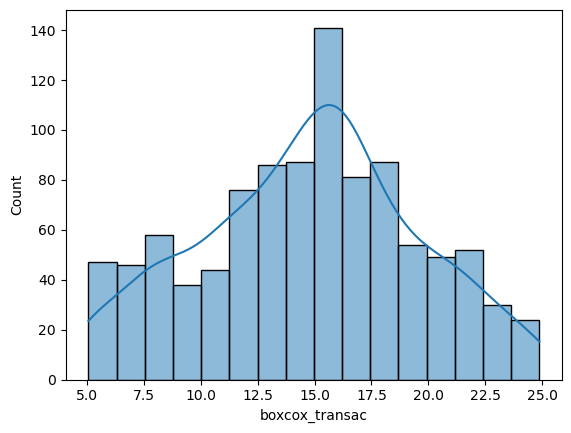

In [53]:
#23. menampilkan distribusi quantity pada hasil boxcox
sns.histplot(dataclean['boxcox_transac'], kde = True)
plt.show()

Setelah melakukan pengecekan pada setiap data numeric yang ada pada kolom dapat terlihat bahwasannya setelah di transform-pun tidak ada kolom numeric yang berdistribusi normal. Yang mengindikasikan bahwa distribusi pembelian (baik terhadap jumlah, harga/item, dan total transaksi) pada pelanggan cenderung tidak simetris dan terdapat variasi antar pelanggannya.

In [54]:
#data cleaning distribusi 24, mengubah format penulisan date yang awalnya menggunakan / sebagai pemisah menjadi menggunkan - lalu mengubah format type datanya menjadi date
dataclean['date'] = dataclean['date'].str.replace('/','-')
dataclean['date'] = pd.to_datetime(dataclean['date'], format='%m-%d-%Y')
dataclean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            1000 non-null   int64         
 1   date                1000 non-null   datetime64[ns]
 2   item_name           1000 non-null   object        
 3   item_type           1000 non-null   object        
 4   item_price          1000 non-null   int64         
 5   quantity            1000 non-null   int64         
 6   transaction_amount  1000 non-null   int64         
 7   transaction_type    1000 non-null   object        
 8   received_by         1000 non-null   object        
 9   time_of_sale        1000 non-null   object        
 10  log_quantity        1000 non-null   float64       
 11  sqrt_quantity       1000 non-null   float64       
 12  boxcox_quantity     1000 non-null   float64       
 13  log_itemp           1000 non-null   float64      

In [55]:
#data cleaning distribusi 25, mengubah type data object menjadi category agar memudahkan dalam melakukan penelitian lanjutan
cat_cols = ['transaction_type', 'item_name', 'item_type', 'received_by', 'time_of_sale']

for col in cat_cols:
    dataclean[col] = dataclean[col].astype('category')

dataclean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            1000 non-null   int64         
 1   date                1000 non-null   datetime64[ns]
 2   item_name           1000 non-null   category      
 3   item_type           1000 non-null   category      
 4   item_price          1000 non-null   int64         
 5   quantity            1000 non-null   int64         
 6   transaction_amount  1000 non-null   int64         
 7   transaction_type    1000 non-null   category      
 8   received_by         1000 non-null   category      
 9   time_of_sale        1000 non-null   category      
 10  log_quantity        1000 non-null   float64       
 11  sqrt_quantity       1000 non-null   float64       
 12  boxcox_quantity     1000 non-null   float64       
 13  log_itemp           1000 non-null   float64      

In [56]:
#Ringkasan hasil cleaning

print('RINGKASAN HASIL DATA CLEANING')
print(f'Jumlah baris data awal          : {len(data_ff)}')
print(f'Jumlah baris data cleaning      : {len(dataclean)}')
print("Missing value ditangani         : transaction_type → diisi random choice probability")
print("Dupikat sebelum                 : 0")
print("Dupikat sesudah                 : 0")
print(f"jumlah outlier                  : {jumlah_outlier}")
print("Fitur baru ditambahkan          : Tidak ada")

RINGKASAN HASIL DATA CLEANING
Jumlah baris data awal          : 1000
Jumlah baris data cleaning      : 1000
Missing value ditangani         : transaction_type → diisi random choice probability
Dupikat sebelum                 : 0
Dupikat sesudah                 : 0
jumlah outlier                  : 44
Fitur baru ditambahkan          : Tidak ada


#### Data Manipulation

In [57]:
#data manipulation 1, melakukan filtering

In [58]:
#filtering transaksi terbesar
high_sales = dataclean[dataclean['transaction_amount']>500]
high_sales.head(10)

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale,log_quantity,sqrt_quantity,boxcox_quantity,log_itemp,sqrt_itemp,boxcox_itemp,log_transac,sqrt_transac,boxcox_transac
15,16,2022-04-14,Sandwich,Fastfood,60,11,660,Online,Mrs.,Midnight,2.484907,3.316625,6.752440,4.110874,7.745967,1.081282,6.493754,25.690465,22.204276
20,21,2022-12-21,Cold coffee,Beverages,40,15,600,Cash,Mr.,Evening,2.772589,3.872983,8.878482,3.713572,6.324555,1.069085,6.398595,24.494897,21.435255
30,31,2022-09-14,Cold coffee,Beverages,40,13,520,Online,Mrs.,Evening,2.639057,3.605551,7.835737,3.713572,6.324555,1.069085,6.255750,22.803509,20.324317
33,34,2023-02-04,Frankie,Fastfood,50,12,600,Online,Mrs.,Evening,2.564949,3.464102,7.299668,3.931826,7.071068,1.076345,6.398595,24.494897,21.435255
47,48,2023-02-23,Sandwich,Fastfood,60,14,840,Online,Mr.,Afternoon,2.708050,3.741657,8.361711,4.110874,7.745967,1.081282,6.734592,28.982753,24.259564
50,51,2022-05-16,Frankie,Fastfood,50,15,750,Online,Mrs.,Morning,2.772589,3.872983,8.878482,3.931826,7.071068,1.076345,6.621406,27.386128,23.273714
54,55,2022-05-07,Sandwich,Fastfood,60,10,600,Cash,Mr.,Night,2.397895,3.162278,6.192771,4.110874,7.745967,1.081282,6.398595,24.494897,21.435255
69,70,2022-05-09,Cold coffee,Beverages,40,14,560,Cash,Mrs.,Morning,2.708050,3.741657,8.361711,3.713572,6.324555,1.069085,6.329721,23.664319,20.893210
71,72,2023-03-09,Frankie,Fastfood,50,13,650,Online,Mr.,Afternoon,2.639057,3.605551,7.835737,3.931826,7.071068,1.076345,6.478510,25.495098,22.079486
79,80,2022-05-24,Frankie,Fastfood,50,13,650,Cash,Mr.,Evening,2.639057,3.605551,7.835737,3.931826,7.071068,1.076345,6.478510,25.495098,22.079486


In [59]:
#data manipulation 2, melakukan sorting
#sorting 1, melakukan sorting berdasarkan transaction_amount untuk melihat berapa transaction_amount paling tinggi
dataclean.sort_values(
    by='transaction_amount',
    ascending=False
).head(10)

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale,log_quantity,sqrt_quantity,boxcox_quantity,log_itemp,sqrt_itemp,boxcox_itemp,log_transac,sqrt_transac,boxcox_transac
585,586,2022-05-22,Sandwich,Fastfood,60,15,900,Online,Mr.,Night,2.772589,3.872983,8.878482,4.110874,7.745967,1.081282,6.803505,30.0,24.877703
95,96,2022-08-22,Sandwich,Fastfood,60,15,900,Cash,Mr.,Morning,2.772589,3.872983,8.878482,4.110874,7.745967,1.081282,6.803505,30.0,24.877703
709,710,2023-03-15,Sandwich,Fastfood,60,15,900,Cash,Mr.,Night,2.772589,3.872983,8.878482,4.110874,7.745967,1.081282,6.803505,30.0,24.877703
491,492,2022-07-11,Sandwich,Fastfood,60,15,900,Cash,Mr.,Afternoon,2.772589,3.872983,8.878482,4.110874,7.745967,1.081282,6.803505,30.0,24.877703
624,625,2022-06-17,Sandwich,Fastfood,60,15,900,Online,Mr.,Morning,2.772589,3.872983,8.878482,4.110874,7.745967,1.081282,6.803505,30.0,24.877703
905,906,2022-04-04,Sandwich,Fastfood,60,15,900,Cash,Mr.,Afternoon,2.772589,3.872983,8.878482,4.110874,7.745967,1.081282,6.803505,30.0,24.877703
476,477,2023-02-13,Sandwich,Fastfood,60,15,900,Cash,Mrs.,Midnight,2.772589,3.872983,8.878482,4.110874,7.745967,1.081282,6.803505,30.0,24.877703
893,894,2023-03-19,Sandwich,Fastfood,60,15,900,Cash,Mr.,Morning,2.772589,3.872983,8.878482,4.110874,7.745967,1.081282,6.803505,30.0,24.877703
639,640,2023-01-04,Sandwich,Fastfood,60,15,900,Online,Mr.,Night,2.772589,3.872983,8.878482,4.110874,7.745967,1.081282,6.803505,30.0,24.877703
543,544,2022-12-14,Sandwich,Fastfood,60,15,900,Online,Mrs.,Morning,2.772589,3.872983,8.878482,4.110874,7.745967,1.081282,6.803505,30.0,24.877703


In [60]:
# sorting 3, melakukan sorting untuk melihat apakah quantity mempengaruhi transaction_amount
dataclean.sort_values(
    by='quantity',
    ascending=False
).head(10)

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale,log_quantity,sqrt_quantity,boxcox_quantity,log_itemp,sqrt_itemp,boxcox_itemp,log_transac,sqrt_transac,boxcox_transac
626,627,2022-06-22,Sugarcane juice,Beverages,25,15,375,Online,Mr.,Afternoon,2.772589,3.872983,8.878482,3.258097,5.000000,1.048063,5.929589,19.364917,17.971628
476,477,2023-02-13,Sandwich,Fastfood,60,15,900,Cash,Mrs.,Midnight,2.772589,3.872983,8.878482,4.110874,7.745967,1.081282,6.803505,30.000000,24.877703
716,717,2022-10-11,Sugarcane juice,Beverages,25,15,375,Online,Mrs.,Evening,2.772589,3.872983,8.878482,3.258097,5.000000,1.048063,5.929589,19.364917,17.971628
718,719,2022-05-09,Vadapav,Fastfood,20,15,300,Cash,Mrs.,Midnight,2.772589,3.872983,8.878482,3.044522,4.472136,1.034500,5.707110,17.320508,16.502955
542,543,2022-04-10,Aalopuri,Fastfood,20,15,300,Cash,Mrs.,Evening,2.772589,3.872983,8.878482,3.044522,4.472136,1.034500,5.707110,17.320508,16.502955
721,722,2022-09-14,Vadapav,Fastfood,20,15,300,Cash,Mr.,Midnight,2.772589,3.872983,8.878482,3.044522,4.472136,1.034500,5.707110,17.320508,16.502955
135,136,2022-08-24,Aalopuri,Fastfood,20,15,300,Online,Mr.,Morning,2.772589,3.872983,8.878482,3.044522,4.472136,1.034500,5.707110,17.320508,16.502955
137,138,2022-09-01,Sandwich,Fastfood,60,15,900,Online,Mr.,Night,2.772589,3.872983,8.878482,4.110874,7.745967,1.081282,6.803505,30.000000,24.877703
1,2,2022-08-23,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon,2.772589,3.872983,8.878482,3.044522,4.472136,1.034500,5.707110,17.320508,16.502955
491,492,2022-07-11,Sandwich,Fastfood,60,15,900,Cash,Mr.,Afternoon,2.772589,3.872983,8.878482,4.110874,7.745967,1.081282,6.803505,30.000000,24.877703


In [61]:
#sorting 4, melakukan sorting untuk melihat apakah item_price mempengaruhi transaction_amount
dataclean.sort_values(
    by='item_price',
    ascending=False
).head(10)

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale,log_quantity,sqrt_quantity,boxcox_quantity,log_itemp,sqrt_itemp,boxcox_itemp,log_transac,sqrt_transac,boxcox_transac
704,705,2022-10-07,Sandwich,Fastfood,60,6,360,Online,Mr.,Evening,1.945910,2.449490,3.791061,4.110874,7.745967,1.081282,5.888878,18.973666,17.694953
234,235,2022-11-29,Sandwich,Fastfood,60,10,600,Cash,Mrs.,Afternoon,2.397895,3.162278,6.192771,4.110874,7.745967,1.081282,6.398595,24.494897,21.435255
913,914,2023-03-01,Sandwich,Fastfood,60,14,840,Cash,Mr.,Night,2.708050,3.741657,8.361711,4.110874,7.745967,1.081282,6.734592,28.982753,24.259564
194,195,2022-04-23,Sandwich,Fastfood,60,4,240,Cash,Mrs.,Night,1.609438,2.000000,2.444066,4.110874,7.745967,1.081282,5.484797,15.491933,15.136713
195,196,2022-06-25,Sandwich,Fastfood,60,3,180,Cash,Mr.,Evening,1.386294,1.732051,1.709325,4.110874,7.745967,1.081282,5.198497,13.416408,13.514974
910,911,2022-04-09,Sandwich,Fastfood,60,1,60,Cash,Mr.,Evening,0.693147,1.000000,0.000000,4.110874,7.745967,1.081282,4.110874,7.745967,8.543139
907,908,2023-03-06,Sandwich,Fastfood,60,7,420,Cash,Mrs.,Night,2.079442,2.645751,4.421195,4.110874,7.745967,1.081282,6.042633,20.493902,18.759185
905,906,2022-04-04,Sandwich,Fastfood,60,15,900,Cash,Mr.,Afternoon,2.772589,3.872983,8.878482,4.110874,7.745967,1.081282,6.803505,30.000000,24.877703
614,615,2022-08-14,Sandwich,Fastfood,60,14,840,Cash,Mr.,Morning,2.708050,3.741657,8.361711,4.110874,7.745967,1.081282,6.734592,28.982753,24.259564
220,221,2023-03-26,Sandwich,Fastfood,60,1,60,Online,Mr.,Evening,0.693147,1.000000,0.000000,4.110874,7.745967,1.081282,4.110874,7.745967,8.543139


In [62]:
#data manipulation 5, melakukan groupby untuk melakukan agregasi untuk melihahat apa saja yang mempengaruhi transaction_amount
group_analysis = dataclean.groupby(
    ['item_type','item_name', 'transaction_type'],
    observed=True
).agg({
    'transaction_amount':['mean', 'sum'],
    'quantity':'sum',
    'order_id':'count'
})

group_analysis

transaction_amount        quantity  \
                                                         mean    sum      sum   
item_type item_name       transaction_type                                      
Beverages Cold coffee     Cash                     354.761905  29800      745   
                          Online                   320.000000  24640      616   
          Sugarcane juice Cash                     206.896552  18000      720   
                          Online                   211.363636  13950      558   
Fastfood  Aalopuri        Cash                     154.473684  11740      587   
                          Online                   157.586207   9140      457   
          Frankie         Cash                     439.705882  29900      598   
                          Online                   388.732394  27600      552   
          Panipuri        Cash                     152.564103  11900      595   
                          Online                   175.277778  12620      631   
          Sandwich        Cash                     533.333333  38400      640   
                          Online                   481.052632  27420      457   
          Vadapav         Cash                     158.082192  11540      577   
                          Online                   140.655738   8580      429   

                                           order_id  
                                              count  
item_type item_name       transaction_type           
Beverages Cold coffee     Cash                   84  
                          Online                 77  
          Sugarcane juice Cash                   87  
                          Online                 66  
Fastfood  Aalopuri        Cash                   76  
                          Online                 58  
          Frankie         Cash                   68  
                          Online                 71  
          Panipuri        Cash                   78  
                          Online                 72  
          Sandwich        Cash                   72  
                          Online                 57  
          Vadapav         Cash                   73  
                          Online                 61

In [63]:
#data manipulation 6, saya tidak melakukan feature engineering pada data saya karena kolom transaction_amount sudah merupakan bentuk dari perkalian quantity dan item_price

In [64]:
#data manipulation 7, saya mengdrop kolom yang sekiranya tidak terpakai dan membuat copy untuk data cleaning final
dataclean_final = dataclean.copy()
dataclean_final = dataclean_final.drop(columns=[
    'log_quantity',               
    'sqrt_quantity',              
    'boxcox_quantity',            
    'log_itemp',                  
    'sqrt_itemp',                 
    'boxcox_itemp',               
    'log_transac',                
    'sqrt_transac',              
    'boxcox_transac'
])

In [65]:
dataclean_final.head(5)

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,1,2022-07-03,Aalopuri,Fastfood,20,13,260,Cash,Mr.,Night
1,2,2022-08-23,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon
2,3,2022-11-20,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon
3,4,2023-02-03,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night
4,5,2022-10-02,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening


#### Reading dan Extraction Data

In [66]:
#Reading dan mengekstrak data dataclean_final (memanggil dataclean_final untuk melakukan tahapan visualisasi)
dataclean_final

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,1,2022-07-03,Aalopuri,Fastfood,20,13,260,Cash,Mr.,Night
1,2,2022-08-23,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon
2,3,2022-11-20,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon
3,4,2023-02-03,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night
4,5,2022-10-02,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening
...,...,...,...,...,...,...,...,...,...,...
995,996,2023-03-19,Frankie,Fastfood,50,10,500,Cash,Mrs.,Evening
996,997,2022-09-20,Sandwich,Fastfood,60,7,420,Online,Mr.,Evening
997,998,2023-01-26,Sandwich,Fastfood,60,13,780,Cash,Mr.,Evening
998,999,2022-08-27,Panipuri,Fastfood,20,5,100,Cash,Mrs.,Afternoon


In [67]:
#melakukan pengecekan type data, missing value dan isi kolum dengan fungsi info()
dataclean_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            1000 non-null   int64         
 1   date                1000 non-null   datetime64[ns]
 2   item_name           1000 non-null   category      
 3   item_type           1000 non-null   category      
 4   item_price          1000 non-null   int64         
 5   quantity            1000 non-null   int64         
 6   transaction_amount  1000 non-null   int64         
 7   transaction_type    1000 non-null   category      
 8   received_by         1000 non-null   category      
 9   time_of_sale        1000 non-null   category      
dtypes: category(5), datetime64[ns](1), int64(4)
memory usage: 45.0 KB


Reading dan ekstrak berhasil dibaca dan di import dari cell yang paling diatas

Dari hasil ekstrak dan reading data diatas, dapat dilihat bahwa pada data yang sudah di clean hanya terdapat data type categoric,numeric, dan type waktu

In [68]:
#data reading and extraction data, head() untuk melihat ada kolom apa saja yang ada pada data set yang sudah clean yang saya gunakan
dataclean_final.head() #untuk melihat header atribut

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,1,2022-07-03,Aalopuri,Fastfood,20,13,260,Cash,Mr.,Night
1,2,2022-08-23,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon
2,3,2022-11-20,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon
3,4,2023-02-03,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night
4,5,2022-10-02,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening


In [69]:
dataclean_final.shape

(1000, 10)

In [70]:
dataclean_final.duplicated().sum()

np.int64(0)

In [71]:
dataclean_final.isnull().sum()

order_id              0
date                  0
item_name             0
item_type             0
item_price            0
quantity              0
transaction_amount    0
transaction_type      0
received_by           0
time_of_sale          0
dtype: int64

#### Data Understanding & EDA Awal (fundamentals visualization)

In [72]:
#data UEDA 1, info() saya gunakan untuk melihat data type apa yang ada pada setiap column dan adakah data yang kosong.
dataclean_final.info() #untuk melihat info nilai dari atribut yang ada

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            1000 non-null   int64         
 1   date                1000 non-null   datetime64[ns]
 2   item_name           1000 non-null   category      
 3   item_type           1000 non-null   category      
 4   item_price          1000 non-null   int64         
 5   quantity            1000 non-null   int64         
 6   transaction_amount  1000 non-null   int64         
 7   transaction_type    1000 non-null   category      
 8   received_by         1000 non-null   category      
 9   time_of_sale        1000 non-null   category      
dtypes: category(5), datetime64[ns](1), int64(4)
memory usage: 45.0 KB


In [73]:
#data UEDA 2, memunculkan deksripsi count,mean dsbnya dengan fungsi describe() lalu dibulatkan 1 angka dibelakang koma
dataclean_final[['order_id','item_price','quantity','transaction_amount']].describe().round(1)

,order_id,item_price,quantity,transaction_amount
count,1000.0,1000.0,1000.0,1000.0
mean,500.5,33.3,8.2,275.2
std,288.8,14.9,4.4,204.4
min,1.0,20.0,1.0,20.0
25%,250.8,20.0,4.0,120.0
50%,500.5,25.0,8.0,240.0
75%,750.2,50.0,12.0,360.0
max,1000.0,60.0,15.0,900.0


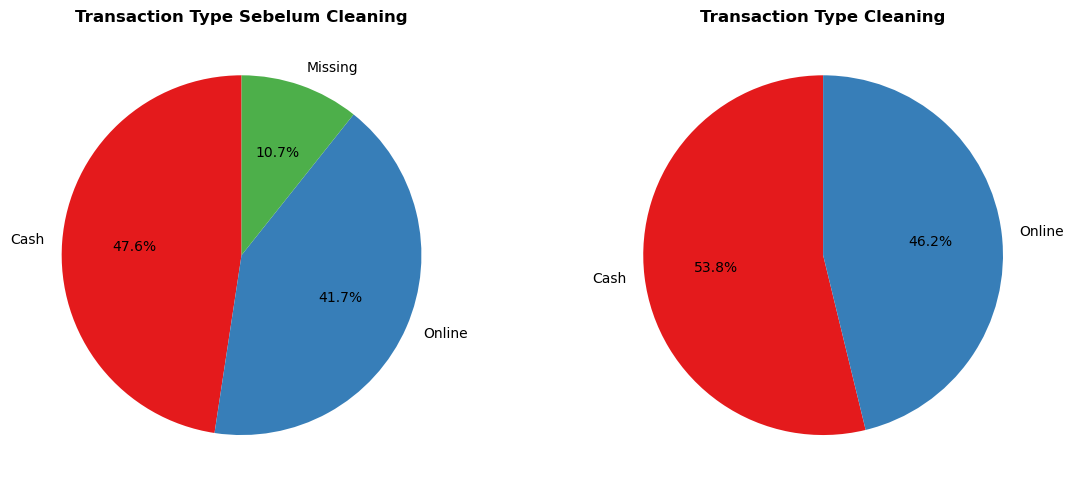

In [74]:
#data UEDA 3, pengecekan distribusi antara sesudah diisi data kosong dan sebelum diisi data kosong
fig, axes = plt.subplots(1, 2, figsize=(12,5))
#sebelum diisi
temp = data_ff.copy()
temp['transaction_type']=temp['transaction_type'].fillna('Missing')
sebelum_diisi_isnull = temp['transaction_type'].value_counts()
axes[0].pie(sebelum_diisi_isnull, labels=sebelum_diisi_isnull.index, autopct='%1.1f%%', startangle=90,
               colors=sns.color_palette('Set1', len(sebelum_diisi_isnull)))
axes[0].set_title('Transaction Type Sebelum Cleaning', fontweight='bold')
                     
#sesudah diisi dengan probability
sesudah_diisi_isnull = dataclean['transaction_type'].value_counts()
axes[1].pie(sesudah_diisi_isnull, labels=sesudah_diisi_isnull.index, autopct='%1.1f%%', startangle=90,
               colors=sns.color_palette('Set1', len(sesudah_diisi_isnull)))
axes[1].set_title('Transaction Type Cleaning', fontweight='bold')
plt.tight_layout()
plt.show()

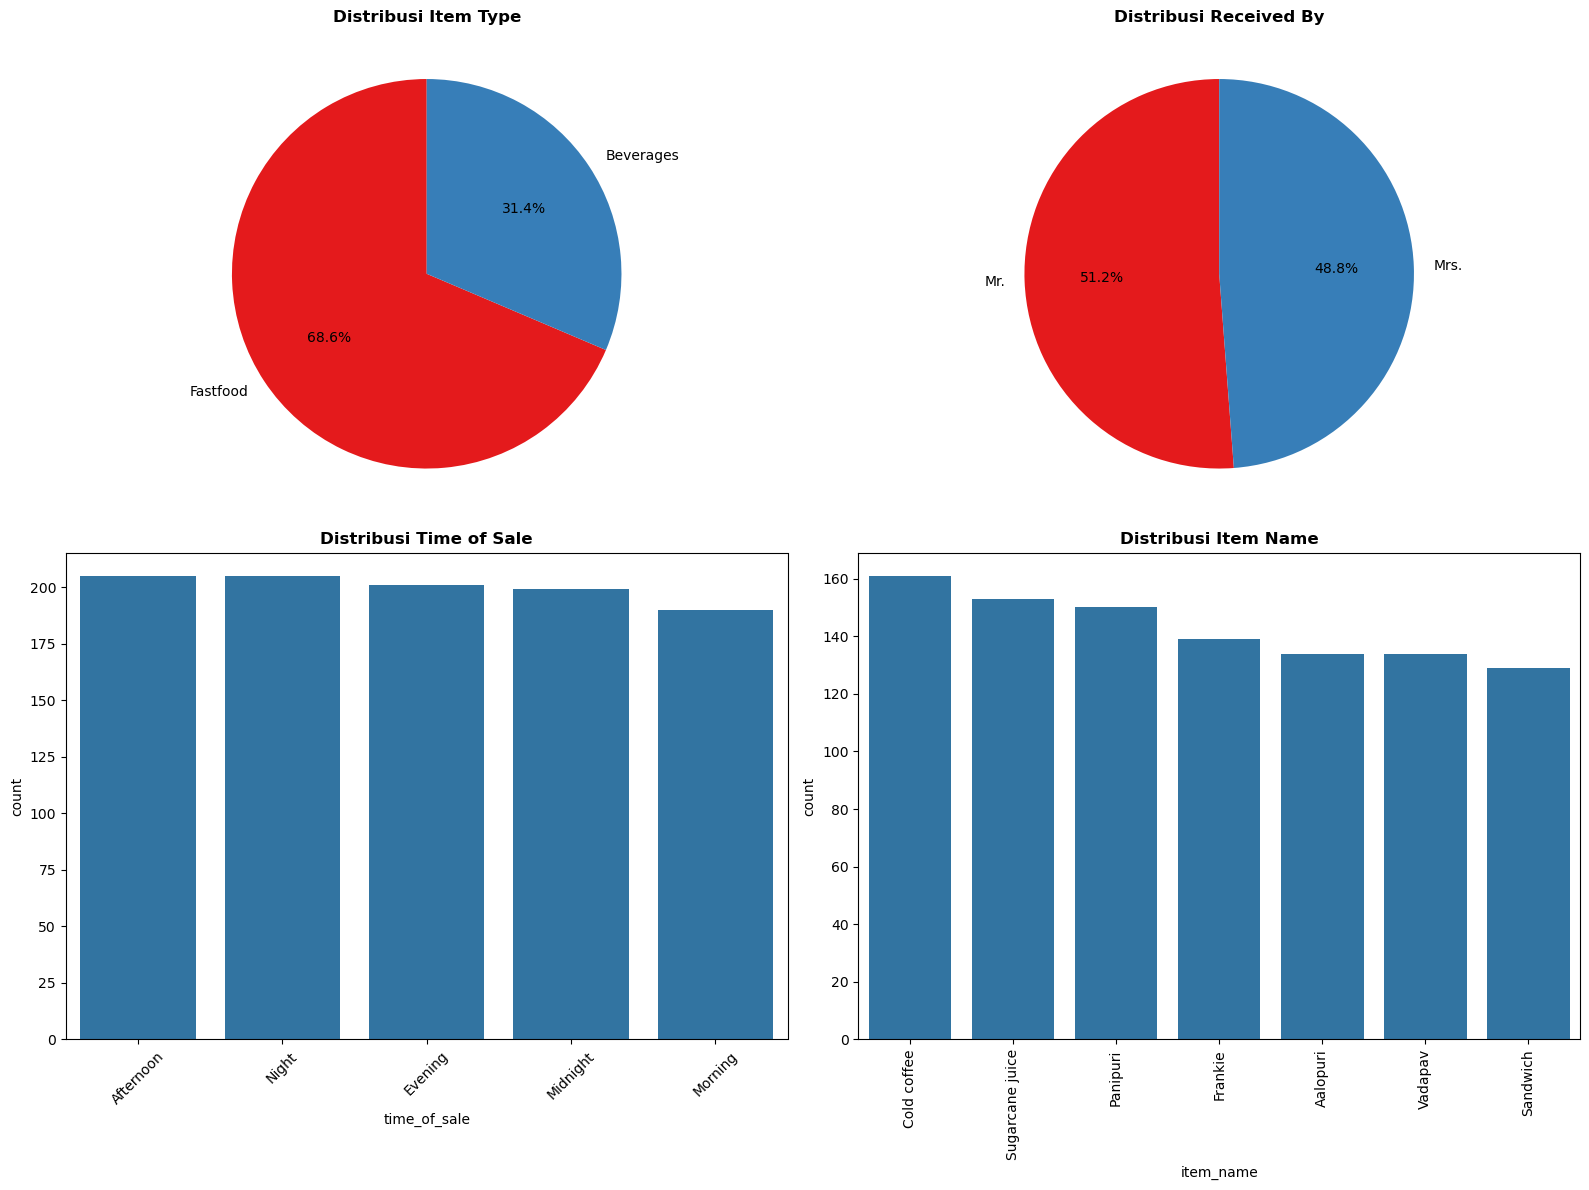

In [75]:
#data UEDA 4, menampilkan seluruh distribusi data object yang ada menggunakan pie chart dan bar chart (alasan menggunakan value counts masih sama dengan alasan pada transaction amount)
fig, axes = plt.subplots(2, 2, figsize=(16,12))

# PIE CHART - item type
item_type_dist = dataclean_final['item_type'].value_counts()

axes[0,0].pie(
    item_type_dist,
    labels=item_type_dist.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set1', len(item_type_dist))
)

axes[0,0].set_title(
    'Distribusi Item Type',
    fontweight='bold'
)

# PIE CHART - received by
received_by_dist = dataclean_final['received_by'] .value_counts()

axes[0,1].pie(
    received_by_dist,
    labels=received_by_dist.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set1', len(received_by_dist))
)

axes[0,1].set_title(
    'Distribusi Received By',
    fontweight='bold'
)

# BAR CHART - time of sale
sns.countplot(
    data=dataclean_final,
    x='time_of_sale',
    order=dataclean_final['time_of_sale'].value_counts().index,
    ax=axes[1,0]
)

axes[1,0].set_title(
    'Distribusi Time of Sale',
    fontweight='bold'
)

axes[1,0].tick_params(axis='x', rotation=45)

# BAR CHART - item name

sns.countplot(
    data=dataclean_final,
    x='item_name',
    order=dataclean_final['item_name'].value_counts().index,
    ax=axes[1,1]
)

axes[1,1].set_title(
    'Distribusi Item Name',
    fontweight='bold'
)

axes[1,1].tick_params(axis='x', rotation=90)

plt.tight_layout()

plt.show()

<Axes: >

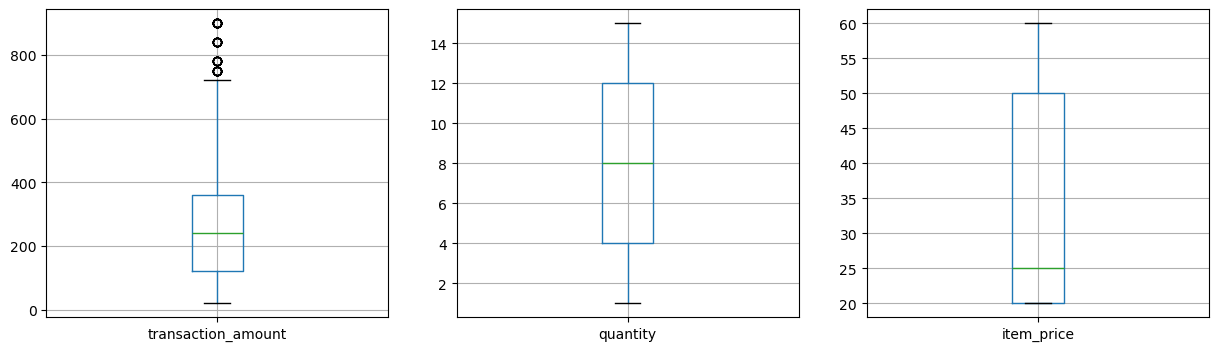

In [76]:
#data UEDA 5, melakukan pengecekan outlier dari data numeric melalui check visualisasi boxplot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
dataclean_final.boxplot(column='transaction_amount', ax=axes[0])
dataclean_final.boxplot(column='quantity', ax=axes[1])
dataclean_final.boxplot(column='item_price', ax=axes[2])

C:\Users\Fadlilah\AppData\Local\Temp\ipykernel_16840\2825258053.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=item_revenue, x='item_name', y='transaction_amount', palette='Reds_r')


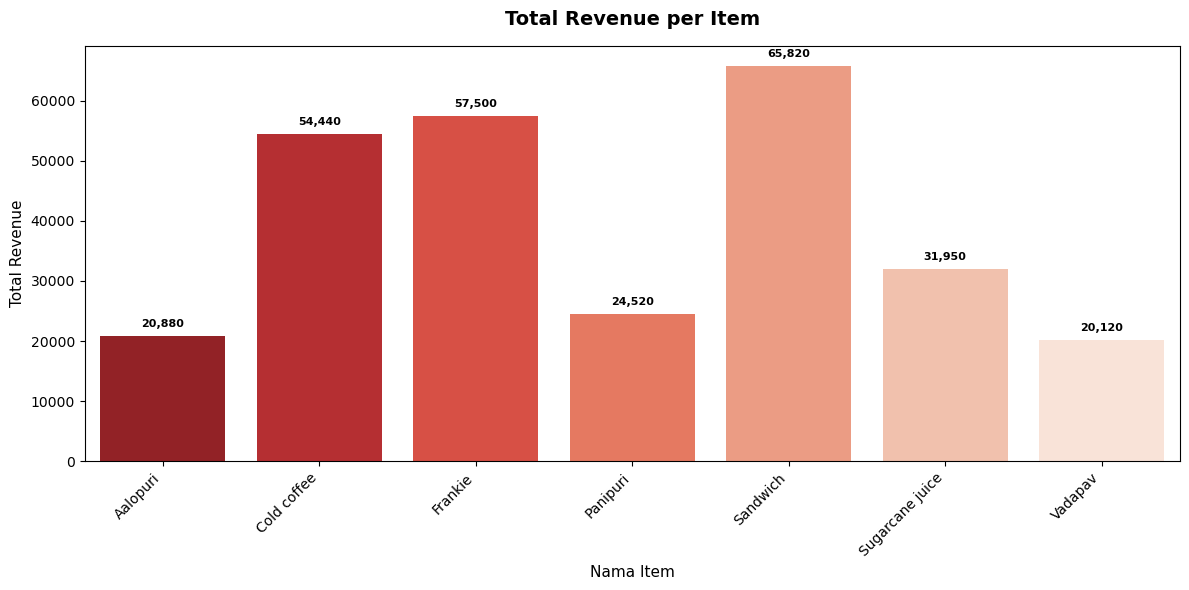

INTERPRETASI: Bar chart di atas menunjukkan total revenue yang dihasilkan oleh setiap produk. Item dengan bar tertinggi adalah kontributor revenue terbesar bagi bisnis Balaji. Produk dengan revenue tinggi perlu dipertahankan stoknya dan dijadikan produk unggulan.


In [77]:
# DATA UEDA 5— Bar Chart: Total Revenue per Item
item_revenue = dataclean_final.groupby('item_name', observed=True)['transaction_amount'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
bars = sns.barplot(data=item_revenue, x='item_name', y='transaction_amount', palette='Reds_r')

# Anotasi nilai di atas bar
for bar in bars.patches:
    bars.annotate(f'{bar.get_height():,.0f}',
                  xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                  xytext=(0, 5), textcoords='offset points',
                  ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.title('Total Revenue per Item', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Nama Item', fontsize=11)
plt.ylabel('Total Revenue', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("""INTERPRETASI: Bar chart di atas menunjukkan total revenue yang dihasilkan oleh setiap produk. Item dengan bar tertinggi adalah kontributor revenue terbesar bagi bisnis Balaji. Produk dengan revenue tinggi perlu dipertahankan stoknya dan dijadikan produk unggulan.""")

In [113]:
item_revenue

,item_name,transaction_amount
0,Sandwich,65820
1,Frankie,57500
2,Cold coffee,54440
3,Sugarcane juice,31950
4,Panipuri,24520
5,Aalopuri,20880
6,Vadapav,20120


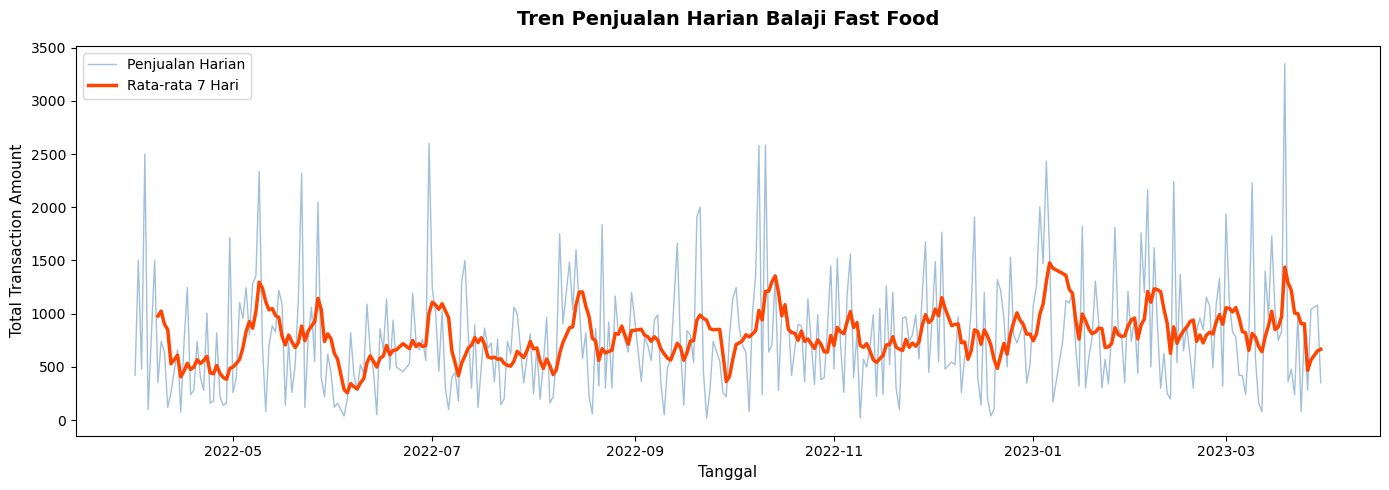

INTERPRETASI: Garis biru menunjukkan fluktuasi penjualan harian, sementara garis merah adalah rata-rata bergerak 7 hari yang memperhalus fluktuasi untuk melihat tren jangka pendek. Jika tren cenderung naik, bisnis sedang bertumbuh. Jika ada pola lonjakan mingguan, bisa dimanfaatkan untuk mengatur jadwal promosi.


In [78]:
# DATA UEDA 6 — Line Chart: Tren Penjualan Harian
daily_sales = dataclean_final.groupby('date')['transaction_amount'].sum().reset_index()
daily_sales['rolling_7'] = daily_sales['transaction_amount'].rolling(7).mean()  # Rata-rata 7 hari

plt.figure(figsize=(14, 5))
plt.plot(daily_sales['date'], daily_sales['transaction_amount'], color='steelblue', alpha=0.5, linewidth=1, label='Penjualan Harian')
plt.plot(daily_sales['date'], daily_sales['rolling_7'], color='orangered', linewidth=2.5, label='Rata-rata 7 Hari')
plt.title('Tren Penjualan Harian Balaji Fast Food', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tanggal', fontsize=11)
plt.ylabel('Total Transaction Amount', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

print("""INTERPRETASI: Garis biru menunjukkan fluktuasi penjualan harian, sementara garis merah adalah rata-rata bergerak 7 hari yang memperhalus fluktuasi untuk melihat tren jangka pendek. Jika tren cenderung naik, bisnis sedang bertumbuh. Jika ada pola lonjakan mingguan, bisa dimanfaatkan untuk mengatur jadwal promosi.""")

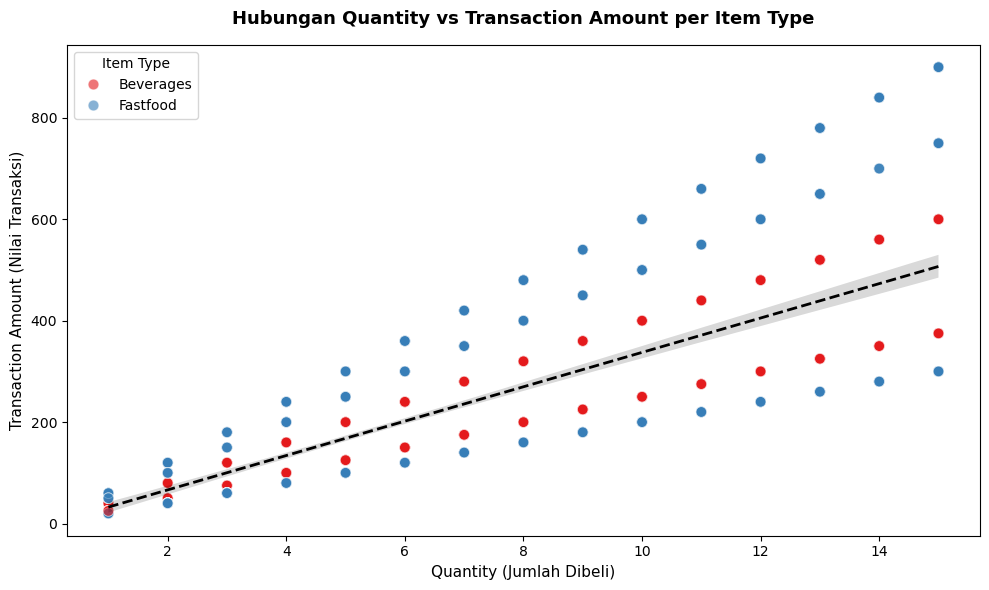

INTERPRETASI: Scatter plot menunjukkan hubungan antara jumlah item yang dibeli dengan total nilai transaksi. Garis putus-putus adalah garis tren regresi linear — jika positif, artinya semakin banyak quantity yang dibeli, semakin tinggi transaction amount (hubungan positif). Warna titik membedakan jenis item (Fastfood vs Beverages), memperlihatkan pola masing-masing kategori.


In [79]:
# DATA UEDA 7 — Scatter Plot: Quantity vs Transaction Amount
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    data=dataclean_final,
    x='quantity',
    y='transaction_amount',
    hue='item_type',
    alpha=0.6,
    s=60,
    palette='Set1'
)

# Tambah garis regresi
sns.regplot(data=dataclean_final, x='quantity', y='transaction_amount',
            scatter=False, color='black', line_kws={'linewidth': 2, 'linestyle': '--', 'label': 'Trend'})

plt.title('Hubungan Quantity vs Transaction Amount per Item Type', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Quantity (Jumlah Dibeli)', fontsize=11)
plt.ylabel('Transaction Amount (Nilai Transaksi)', fontsize=11)
plt.legend(title='Item Type')
plt.tight_layout()
plt.show()

print("""INTERPRETASI: Scatter plot menunjukkan hubungan antara jumlah item yang dibeli dengan total nilai transaksi. Garis putus-putus adalah garis tren regresi linear — jika positif, artinya semakin banyak quantity yang dibeli, semakin tinggi transaction amount (hubungan positif). Warna titik membedakan jenis item (Fastfood vs Beverages), memperlihatkan pola masing-masing kategori.""")

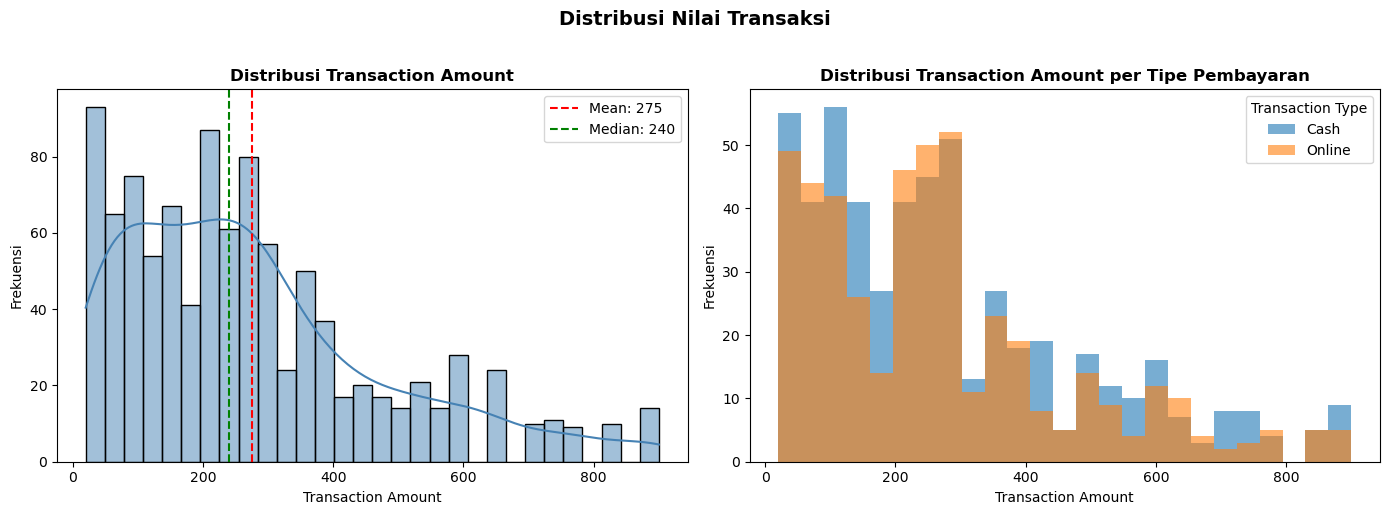

INTERPRETASI: Histogram kiri menunjukkan distribusi keseluruhan transaction amount. Garis merah (mean) dan hijau (median) membantu melihat apakah data simetris atau skewed. Histogram kanan memperlihatkan perbandingan distribusi antara Cash dan Online — jika ada perbedaan bentuk, berarti perilaku belanja berbeda antar metode pembayaran.


In [80]:
# DATA UEDA 8 — Histogram: Distribusi Transaction Amount
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram keseluruhan
sns.histplot(dataclean_final['transaction_amount'], kde=True, ax=axes[0], color='steelblue', bins=30)
axes[0].set_title('Distribusi Transaction Amount', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Transaction Amount')
axes[0].set_ylabel('Frekuensi')
axes[0].axvline(dataclean_final['transaction_amount'].mean(), color='red', linestyle='--', label=f'Mean: {dataclean_final["transaction_amount"].mean():.0f}')
axes[0].axvline(dataclean_final['transaction_amount'].median(), color='green', linestyle='--', label=f'Median: {dataclean_final["transaction_amount"].median():.0f}')
axes[0].legend()

# Histogram berdasarkan transaction_type
for ttype in dataclean_final['transaction_type'].cat.categories:
    subset = dataclean_final[dataclean_final['transaction_type'] == ttype]
    axes[1].hist(subset['transaction_amount'], bins=25, alpha=0.6, label=ttype)

axes[1].set_title('Distribusi Transaction Amount per Tipe Pembayaran', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Transaction Amount')
axes[1].set_ylabel('Frekuensi')
axes[1].legend(title='Transaction Type')

plt.suptitle('Distribusi Nilai Transaksi', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"""INTERPRETASI: Histogram kiri menunjukkan distribusi keseluruhan transaction amount. Garis merah (mean) dan hijau (median) membantu melihat apakah data simetris atau skewed. Histogram kanan memperlihatkan perbandingan distribusi antara Cash dan Online — jika ada perbedaan bentuk, berarti perilaku belanja berbeda antar metode pembayaran.""")

C:\Users\Fadlilah\AppData\Local\Temp\ipykernel_16840\3248787719.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


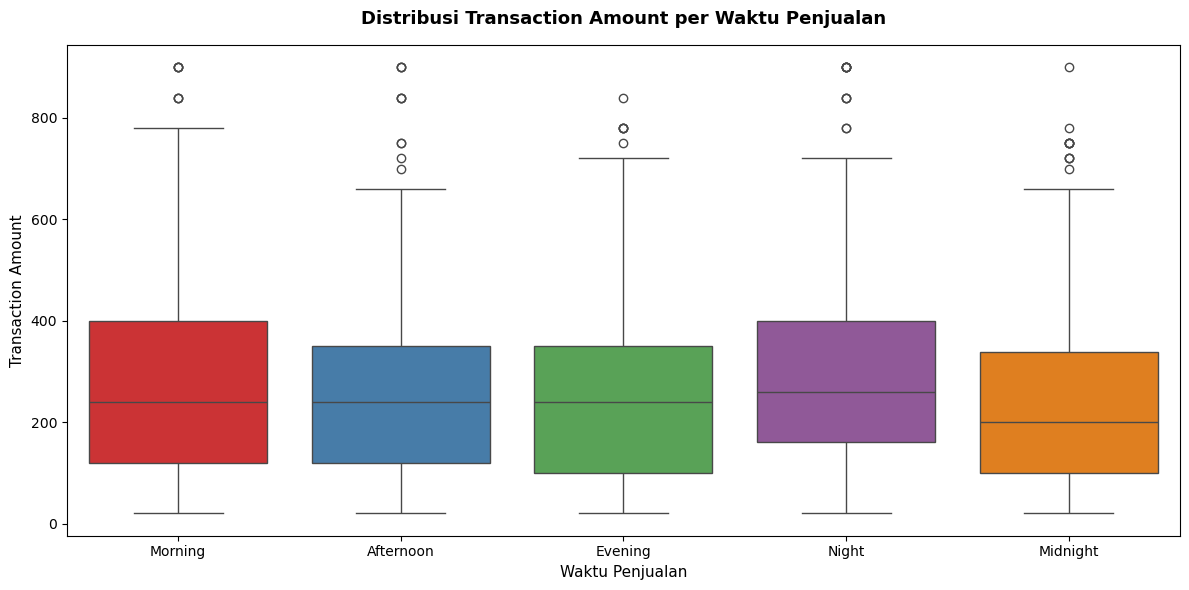

INTERPRETASI:
Boxplot ini memperlihatkan sebaran nilai transaksi untuk setiap periode waktu (pagi, siang, sore, malam).
Periode dengan median (garis tengah kotak) yang lebih tinggi menunjukkan waktu pembelian dengan
nilai transaksi rata-rata lebih besar — berguna untuk menentukan waktu optimal promosi.



In [82]:
# DATA UEDA 8 — Box Plot: Transaction Amount per Time of Sale
order_time = ['Morning', 'Afternoon', 'Evening', 'Night', 'Midnight']
order_time_valid = [t for t in order_time if t in dataclean_final['time_of_sale'].cat.categories]

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=dataclean_final,
    x='time_of_sale',
    y='transaction_amount',
    order=order_time_valid,
    palette='Set1'
)
plt.title('Distribusi Transaction Amount per Waktu Penjualan', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Waktu Penjualan', fontsize=11)
plt.ylabel('Transaction Amount', fontsize=11)
plt.tight_layout()
plt.show()

print("""INTERPRETASI:
Boxplot ini memperlihatkan sebaran nilai transaksi untuk setiap periode waktu (pagi, siang, sore, malam).
Periode dengan median (garis tengah kotak) yang lebih tinggi menunjukkan waktu pembelian dengan
nilai transaksi rata-rata lebih besar — berguna untuk menentukan waktu optimal promosi.
""")

In [83]:
def detect_outliers_iqr(dataclean_final, group_col, value_col):
    """
    Deteksi outlier per kelompok menggunakan metode IQR
    
    Parameters:
    - df: DataFrame
    - group_col: nama kolom untuk pengelompokan (misal: 'time_of_sale')
    - value_col: nama kolom nilai yang akan dicek (misal: 'transaction_amount')
    
    Returns:
    - DataFrame dengan informasi outlier per kelompok
    """
    results = []
    
    for group in dataclean_final[group_col].unique():
        subset = dataclean_final[dataclean_final[group_col] == group][value_col]
        
        Q1 = subset.quantile(0.25)
        Q3 = subset.quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = subset[(subset < lower_bound) | (subset > upper_bound)]
        
        results.append({
            'time_of_sale': group,
            'Q1': Q1,
            'Q3': Q3,
            'IQR': IQR,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'n_outliers': len(outliers),
            'outlier_values': outliers.tolist(),
            'outlier_percentage': (len(outliers) / len(subset)) * 100
        })
    
    return pd.DataFrame(results)

# Jalankan fungsi
outlier_report = detect_outliers_iqr(dataclean_final, 'time_of_sale', 'transaction_amount')
print(outlier_report[['time_of_sale', 'n_outliers', 'outlier_percentage', 'lower_bound', 'upper_bound']])

  time_of_sale  n_outliers  outlier_percentage  lower_bound  upper_bound
0        Night          11            5.365854      -200.00       760.00
1    Afternoon          10            4.878049      -225.00       695.00
2      Evening           6            2.985075      -275.00       725.00
3      Morning           7            3.684211      -300.00       820.00
4     Midnight          11            5.527638      -256.25       693.75


#### Advanced Visualization

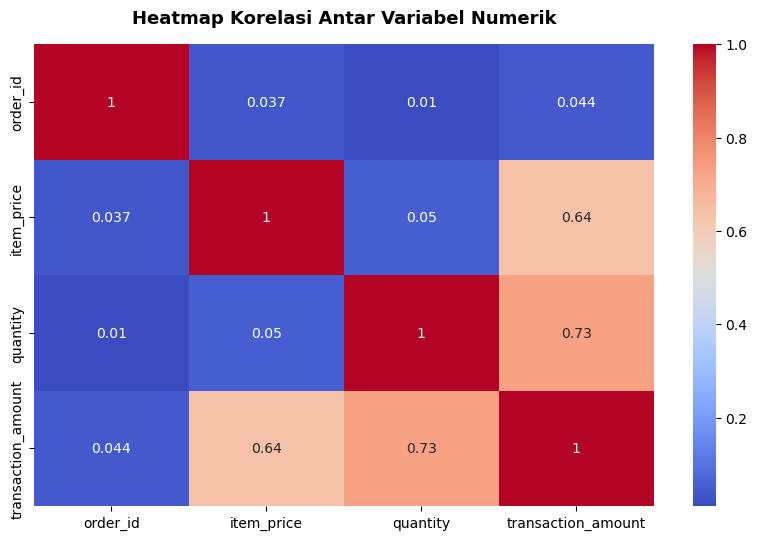

INTERPRETASI: Heatmap menunjukkan korelasi antar variabel numerik: 
• Nilai mendekati +1 → hubungan positif kuat (naik bersama)
• Nilai mendekati -1 → hubungan negatif (berbanding terbalik)
• Nilai mendekati 0  → tidak ada hubungan linear
Perhatikan korelasi transaction_amount dengan quantity dan item_price untuk
memahami faktor apa yang paling mendorong nilai transaksi.



In [84]:
#Advanced Viz 1, melihat korelasi antar kolum numerik menggunakan heatmap
plt.figure(figsize=(10,6))
sns.heatmap(dataclean_final.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Heatmap Korelasi Antar Variabel Numerik', fontsize=13, fontweight='bold', pad=15)
plt.show()
print("""INTERPRETASI: Heatmap menunjukkan korelasi antar variabel numerik: 
• Nilai mendekati +1 → hubungan positif kuat (naik bersama)
• Nilai mendekati -1 → hubungan negatif (berbanding terbalik)
• Nilai mendekati 0  → tidak ada hubungan linear
Perhatikan korelasi transaction_amount dengan quantity dan item_price untuk
memahami faktor apa yang paling mendorong nilai transaksi.
""")

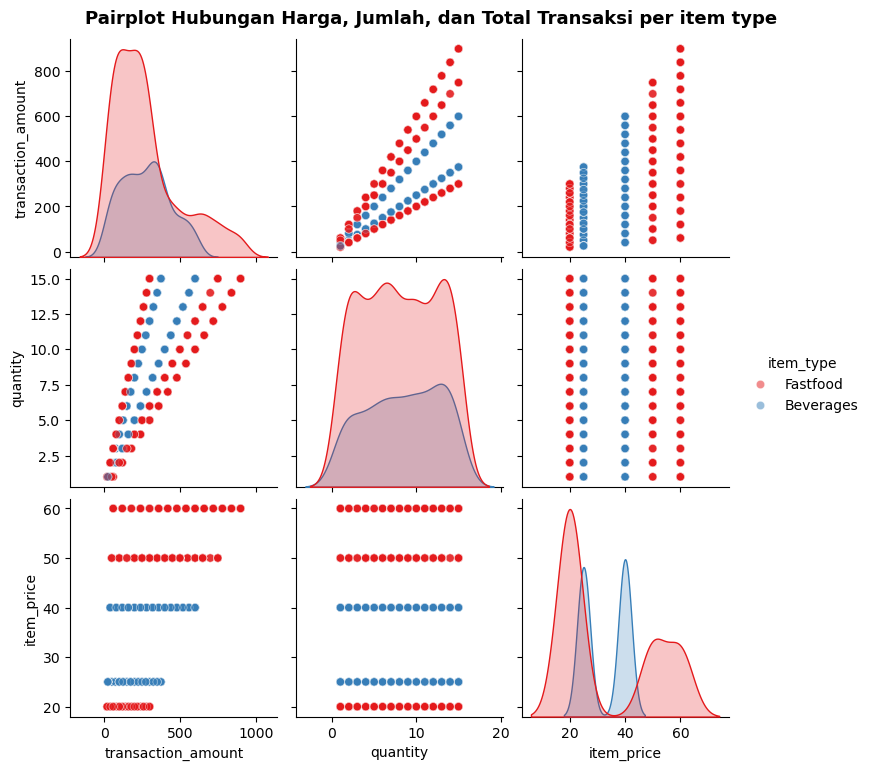

INTERPRETASI:
Pairplot menampilkan semua kombinasi pasangan variabel numerik sekaligus.
Diagonal menunjukkan distribusi masing-masing variabel (KDE).
Warna membedakan kategori item (Fastfood vs Beverages).
Cluster yang terpisah antar warna menandakan perbedaan perilaku yang signifikan
antara dua jenis produk.



In [85]:
# ADVANCED VIZ 2 — Pairplot
pairplot_data = dataclean_final[['transaction_amount', 'quantity', 'item_price', 'item_type']].copy()
pairplot_data['item_type'] = pairplot_data['item_type'].astype(str)

g = sns.pairplot(
    pairplot_data,
    hue='item_type',
    diag_kind='kde',
    plot_kws={'alpha': 0.5},
    palette='Set1'
)
g.fig.suptitle('Pairplot Hubungan Harga, Jumlah, dan Total Transaksi per item type', y=1.02, fontsize=13, fontweight='bold')
plt.show()

print("""INTERPRETASI:
Pairplot menampilkan semua kombinasi pasangan variabel numerik sekaligus.
Diagonal menunjukkan distribusi masing-masing variabel (KDE).
Warna membedakan kategori item (Fastfood vs Beverages).
Cluster yang terpisah antar warna menandakan perbedaan perilaku yang signifikan
antara dua jenis produk.
""")

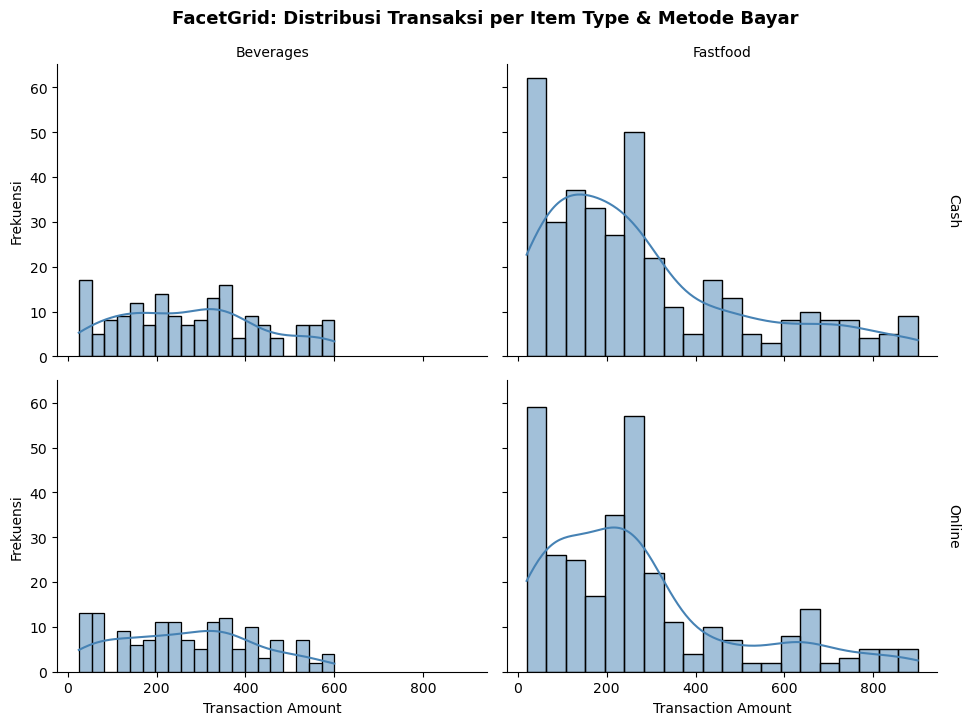

In [86]:
# ADVANCED VIZ 3 — FacetGrid: Distribusi Transaction Amount per Item Type & Transaction Type
g = sns.FacetGrid(
    dataclean,
    col='item_type',
    row='transaction_type',
    height=3.5,
    aspect=1.4,
    margin_titles=True
)
g.map(sns.histplot, 'transaction_amount', kde=True, color='steelblue', bins=20)
g.set_titles(col_template='{col_name}', row_template='{row_name}')
g.set_axis_labels('Transaction Amount', 'Frekuensi')
g.fig.suptitle('FacetGrid: Distribusi Transaksi per Item Type & Metode Bayar', y=1.03, fontsize=13, fontweight='bold')
plt.show()

##### INTERPRETASI:
FacetGrid memperlihatkan distribusi nilai transaksi untuk setiap kombinasi: item type (baris) × transaction type (kolom).
Jika bentuk distribusi berbeda antar panel, artinya kombinasi tersebut memiliki pola belanja yang unik — misalnya pembayaran online untuk Fastfood cenderung menghasilkan transaksi lebih besar.


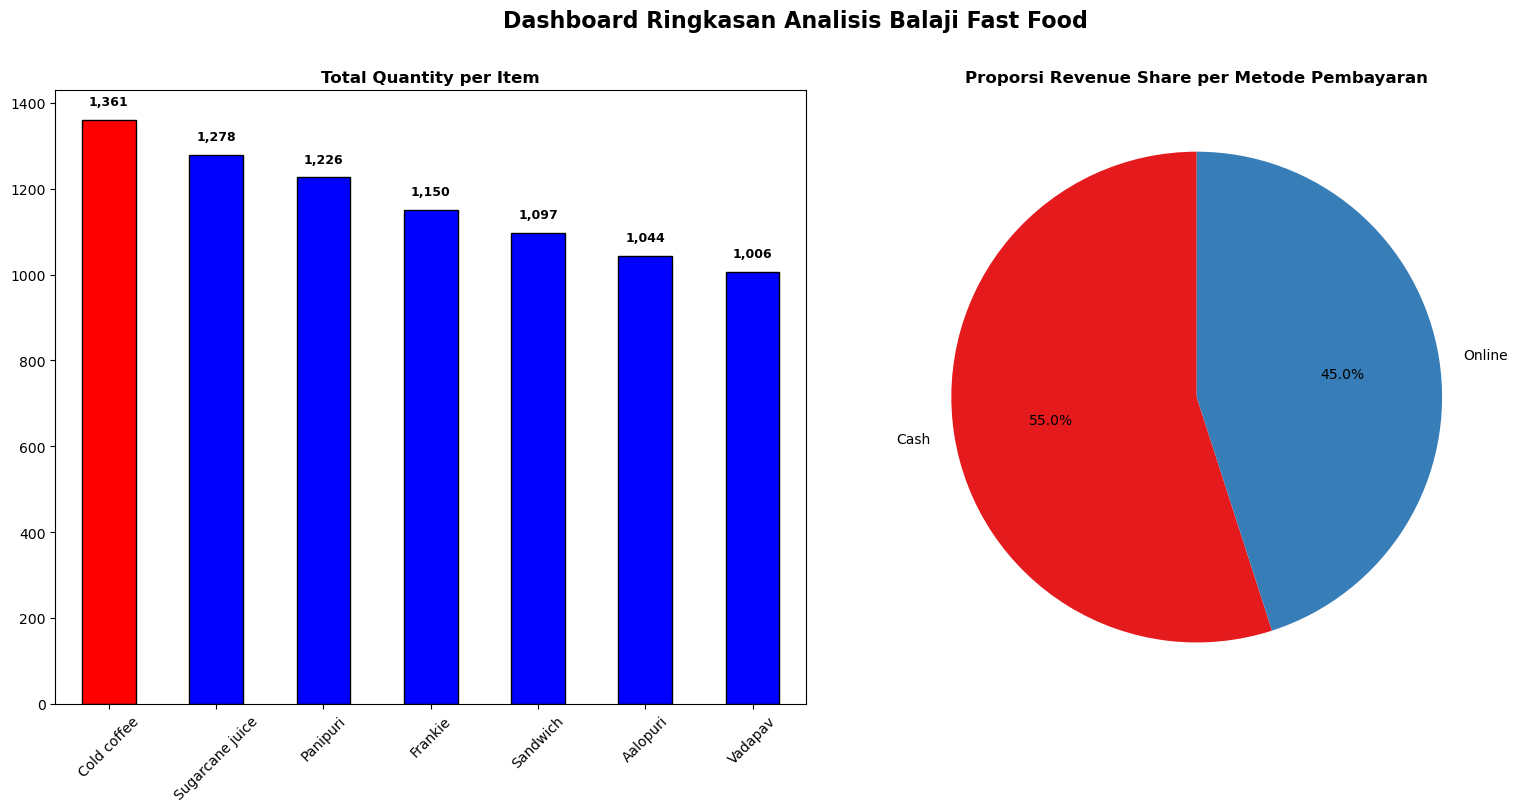

In [87]:
# ADVANCED VIZ 5 — Subplot Gabungan (4 panel dalam 1 figure)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Dashboard Ringkasan Analisis Balaji Fast Food', fontsize=16, fontweight='bold', y=1.01)

# Panel 1: Total Quantity per Item
qty_item = dataclean_final.groupby('item_name', observed=True)['quantity'].sum().sort_values(ascending=False)
#membuat bar plot
ax= axes[0]
colors = ['red' if x == qty_item.max() else 'blue' for x in qty_item]
bar= qty_item.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
# Anotasi dengan perhitungan offset dinamis
max_height = qty_item.max()
for i, (idx, value) in enumerate(qty_item.items()):
    # Offset proporsional terhadap tinggi bar (5% dari max)
    offset = max_height * 0.02
    ax.text(i, value + offset,
            f'{int(value):,}',  # Tambahkan pemisah ribuan
            ha='center', va='bottom',
            fontsize=9, fontweight='bold',
            rotation=0)
axes[0].set_title('Total Quantity per Item', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# Panel 2: Revenue per Transaction Type (Pie)
rev_type = dataclean_final.groupby('transaction_type', observed=True)['transaction_amount'].sum()
axes[1].pie(rev_type, labels=rev_type.index, autopct='%1.1f%%', startangle=90,
               colors=sns.color_palette('Set1', len(rev_type)))
axes[1].set_title('Proporsi Revenue Share per Metode Pembayaran', fontweight='bold')


plt.tight_layout()
plt.show()

##### Interpretasi:
INTERPRETASI Dashboard:
1. Kiri atas pada dashboard ringkasan: Item dengan penjualan terbanyak (berdasarkan quantity), dapat dilihat item dengan penjualan terbanyak ialah cold coffee.
2. Kanan atas pada revune share per metode pembayaran: Proporsi revenue dari Cash vs Online, dapat dilihat bahwasannya proporsi terbanyak berdasarkan metode pembayaran per transaction amount ialah cash.

In [88]:
print(qty_item)
print(rev_type)

item_name
Cold coffee        1361
Sugarcane juice    1278
Panipuri           1226
Frankie            1150
Sandwich           1097
Aalopuri           1044
Vadapav            1006
Name: quantity, dtype: int64
transaction_type
Cash      151280
Online    123950
Name: transaction_amount, dtype: int64


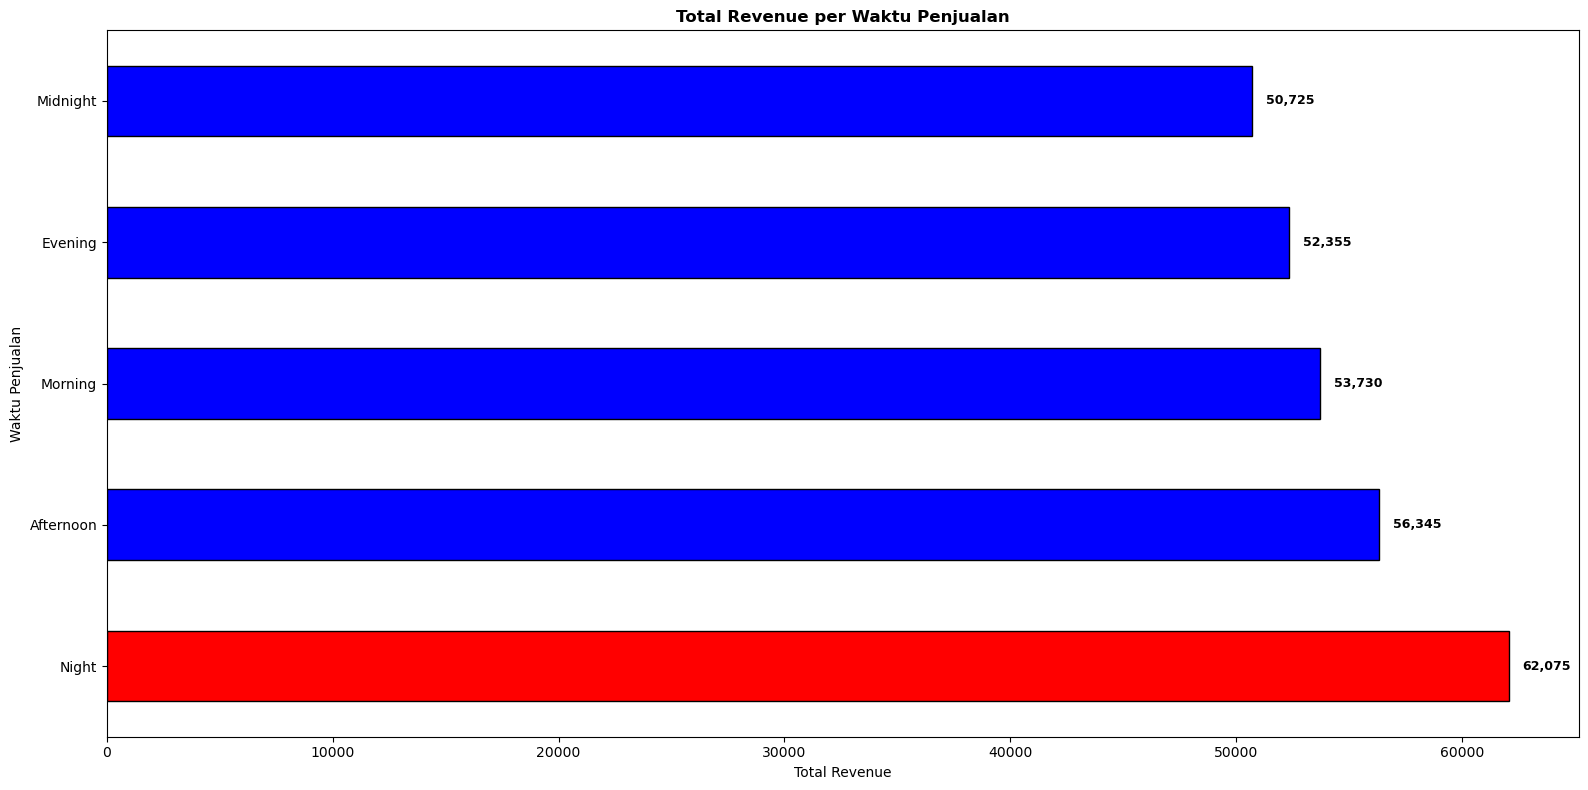

In [89]:
# Panel 3: Revenue per Time of Sale
ig, ax = plt.subplots(figsize=(16,8))
rev_time = dataclean_final.groupby('time_of_sale', observed=True)['transaction_amount'].sum().sort_values(ascending=False)

# Buat plot
colors = ['red' if x == rev_time.max() else 'blue' for x in rev_time]
bars = rev_time.plot(kind='barh', ax=ax, color=colors, edgecolor='black')

# Anotasi
max_value = rev_time.max()
for i, (time, value) in enumerate(rev_time.items()):
    ax.text(value + (max_value * 0.01), i,  # x = value + 1% dari max value
            f'{value:,.0f}',
            va='center', ha='left',
            fontsize=9, fontweight='bold')

ax.set_title('Total Revenue per Waktu Penjualan', fontweight='bold')
ax.set_xlabel('Total Revenue')
ax.set_ylabel('Waktu Penjualan')
plt.tight_layout()
plt.show()

###### INTERPRETASI:
Periode waktu yang menghasilkan revenue tertinggi ialah di malam hari.

In [90]:
rev_time = dataclean_final.groupby('time_of_sale', observed=True)['transaction_amount'].sum().sort_values(ascending=False)
print(rev_time)

time_of_sale
Night        62075
Afternoon    56345
Morning      53730
Evening      52355
Midnight     50725
Name: transaction_amount, dtype: int64


#### Exploratory Data Analysis (EDA)

##### Analysis Univariate

In [91]:
# Univariate 1: Statistik deskriptif kolom numerik
dataclean_final[['transaction_amount', 'quantity', 'item_price']].describe().round(2)

,transaction_amount,quantity,item_price
count,1000.00,1000.00,1000.00
mean,275.23,8.16,33.32
std,204.40,4.41,14.92
min,20.00,1.00,20.00
25%,120.00,4.00,20.00
50%,240.00,8.00,25.00
75%,360.00,12.00,50.00
max,900.00,15.00,60.00


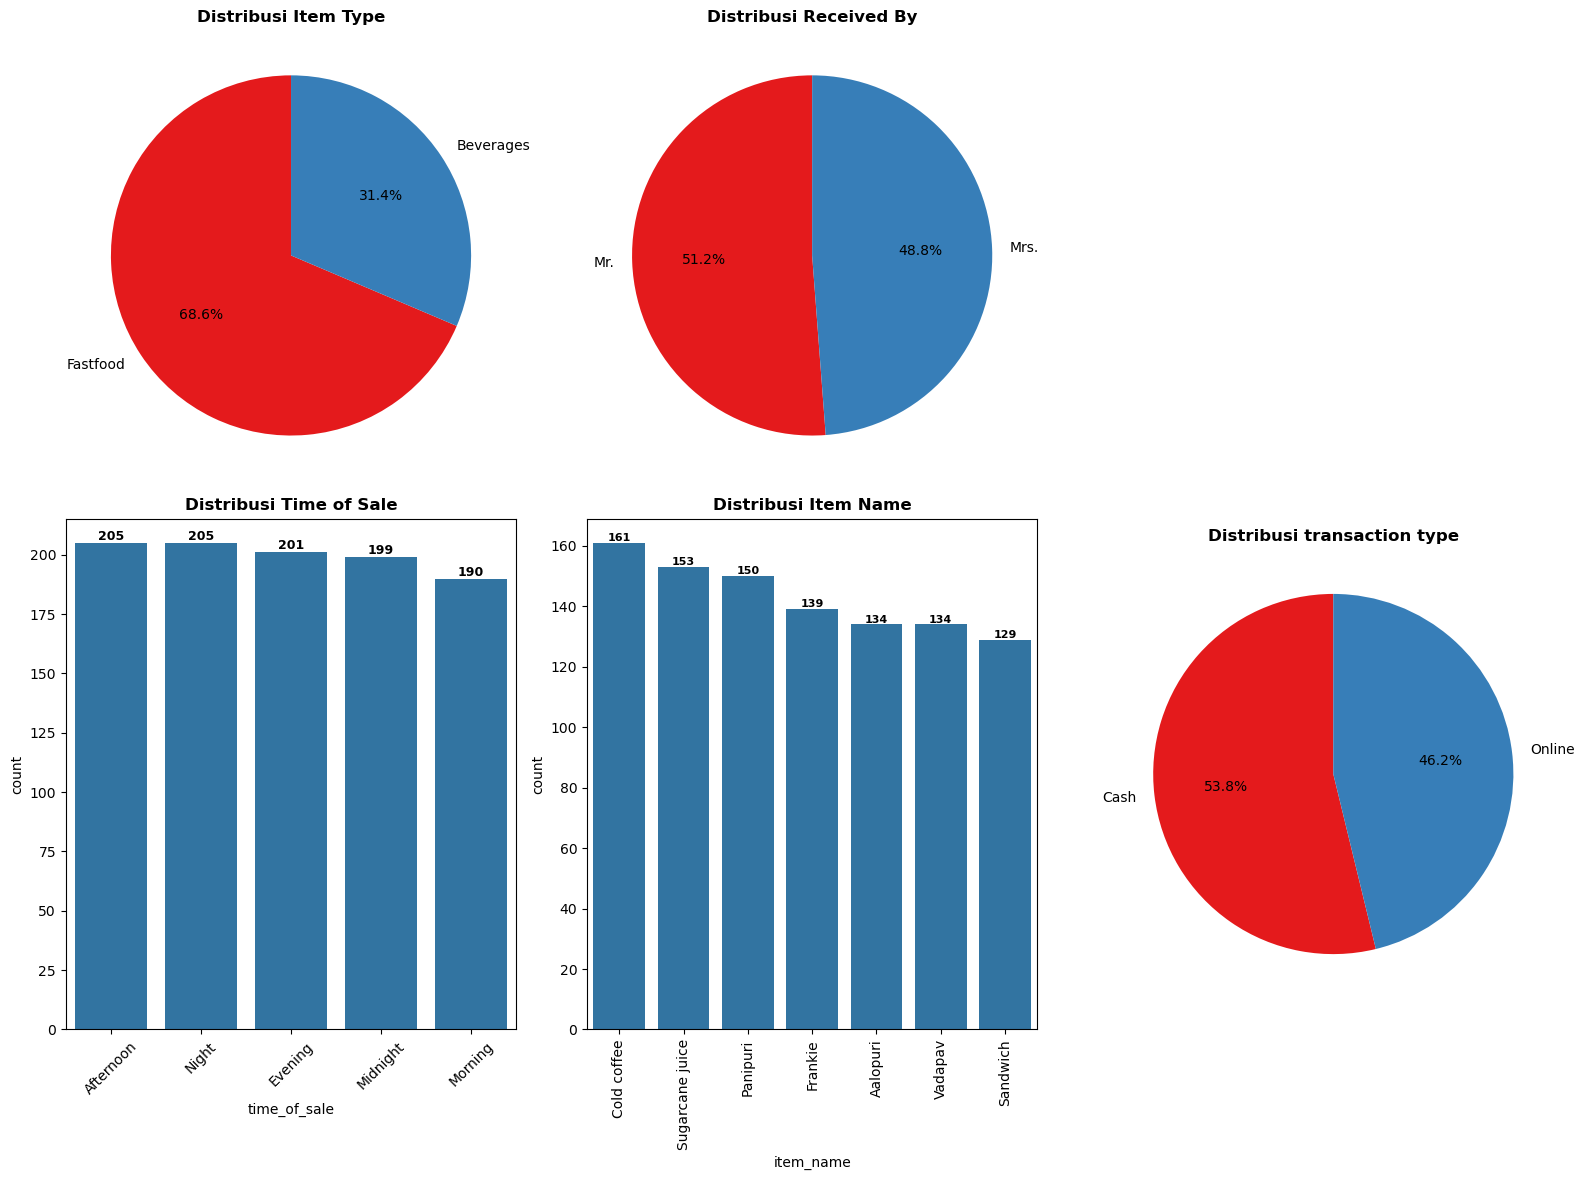


INTERPRETASI:
Analisis univariate menampilkan distribusi frekuensi setiap variabel kategorik.
Item yang paling sering muncul adalah yang paling populer di kalangan pelanggan.
Keseimbangan antara Cash dan Online memberikan gambaran preferensi pembayaran pelanggan.



In [92]:
# Univariate 2, menampilkan seluruh distribusi data object yang ada menggunakan pie chart dan bar chart (alasan menggunakan value counts masih sama dengan alasan pada transaction amount)
fig, axes = plt.subplots(2, 3, figsize=(16,12))

# PIE CHART - item type
item_type_dist = dataclean_final['item_type'].value_counts()

axes[0,0].pie(
    item_type_dist,
    labels=item_type_dist.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set1', len(item_type_dist))
)

axes[0,0].set_title(
    'Distribusi Item Type',
    fontweight='bold'
)

# PIE CHART - received by
received_by_dist = dataclean_final['received_by'] .value_counts()

axes[0,1].pie(
    received_by_dist,
    labels=received_by_dist.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set1', len(received_by_dist))
)

axes[0,1].set_title(
    'Distribusi Received By',
    fontweight='bold'
)

# PIE CHART - transaction type
transaction_type_dist = dataclean_final['transaction_type'] .value_counts()

axes[1,2].pie(
    transaction_type_dist,
    labels=transaction_type_dist.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set1', len(transaction_type_dist))
)

axes[1,2].set_title(
    'Distribusi transaction type',
    fontweight='bold'
)        
# BAR CHART - time of sale
sns.countplot(
    data=dataclean_final,
    x='time_of_sale',
    order=dataclean_final['time_of_sale'].value_counts().index,
    ax=axes[1,0]
)

axes[1,0].set_title(
    'Distribusi Time of Sale',
    fontweight='bold'
)

axes[1,0].tick_params(axis='x', rotation=45)

# ANOTASI TIME OF SALE
for p in axes[1,0].patches:

    axes[1,0].annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

# BAR CHART - item name

sns.countplot(
    data=dataclean_final,
    x='item_name',
    order=dataclean_final['item_name'].value_counts().index,
    ax=axes[1,1]
)

axes[1,1].set_title(
    'Distribusi Item Name',
    fontweight='bold'
)

axes[1,1].tick_params(axis='x', rotation=90)

# ANOTASI ITEM NAME
for p in axes[1,1].patches:

    axes[1,1].annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=8,
        fontweight='bold'
    )

fig.delaxes(axes[0,2])
plt.tight_layout()

plt.show()

print("""
INTERPRETASI:
Analisis univariate menampilkan distribusi frekuensi setiap variabel kategorik.
Item yang paling sering muncul adalah yang paling populer di kalangan pelanggan.
Keseimbangan antara Cash dan Online memberikan gambaran preferensi pembayaran pelanggan.
""")

##### Analysis Bivariate

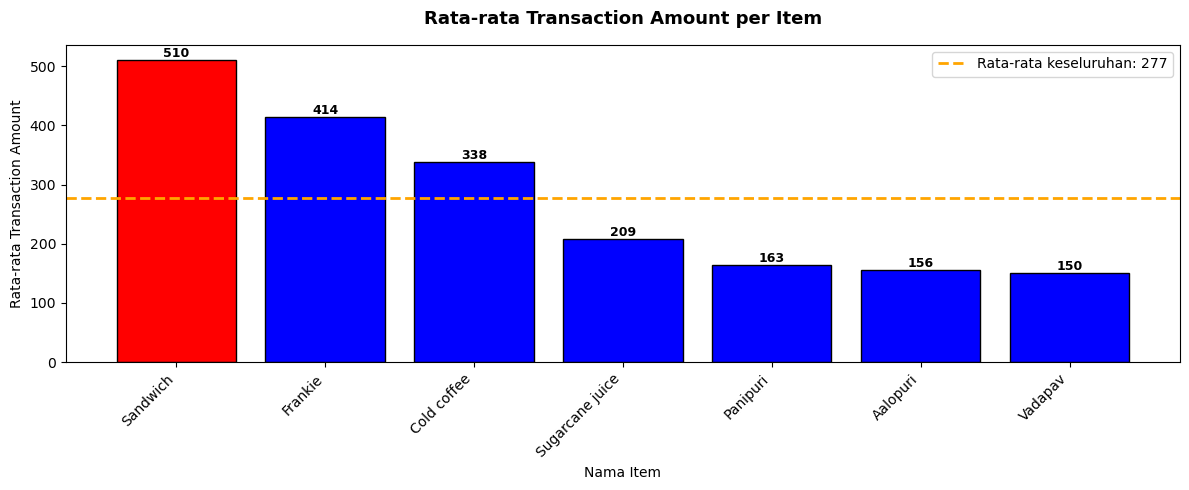


INTERPRETASI:
Grafik ini membandingkan rata-rata nilai transaksi antar item.
Bar merah menandakan item dengan rata-rata transaksi tertinggi.
Garis oranye adalah rata-rata keseluruhan — item di atas garis ini adalah item premium yang sebaiknya dijadikan andalan promosi. Dilihat dari rata-ratanya item sandwich, frankie dan cold coffe dapat dijadikan produk premium



In [93]:
# Bivariate 1: Rata-rata Transaction Amount per Item Name
avg_ta = dataclean_final.groupby('item_name', observed=True)['transaction_amount'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
colors = ['red' if x == avg_ta.max() else 'blue' for x in avg_ta]
bars = plt.bar(avg_ta.index, avg_ta.values, color=colors, edgecolor='black')
# Anotasi
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.0f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )
plt.axhline(avg_ta.mean(), color='orange', linestyle='--', linewidth=2, label=f'Rata-rata keseluruhan: {avg_ta.mean():.0f}')
plt.title('Rata-rata Transaction Amount per Item', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Nama Item')
plt.ylabel('Rata-rata Transaction Amount')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

print("""
INTERPRETASI:
Grafik ini membandingkan rata-rata nilai transaksi antar item.
Bar merah menandakan item dengan rata-rata transaksi tertinggi.
Garis oranye adalah rata-rata keseluruhan — item di atas garis ini adalah item premium yang sebaiknya dijadikan andalan promosi. Dilihat dari rata-ratanya item sandwich, frankie dan cold coffe dapat dijadikan produk premium
""")

C:\Users\Fadlilah\AppData\Local\Temp\ipykernel_16840\1908150918.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


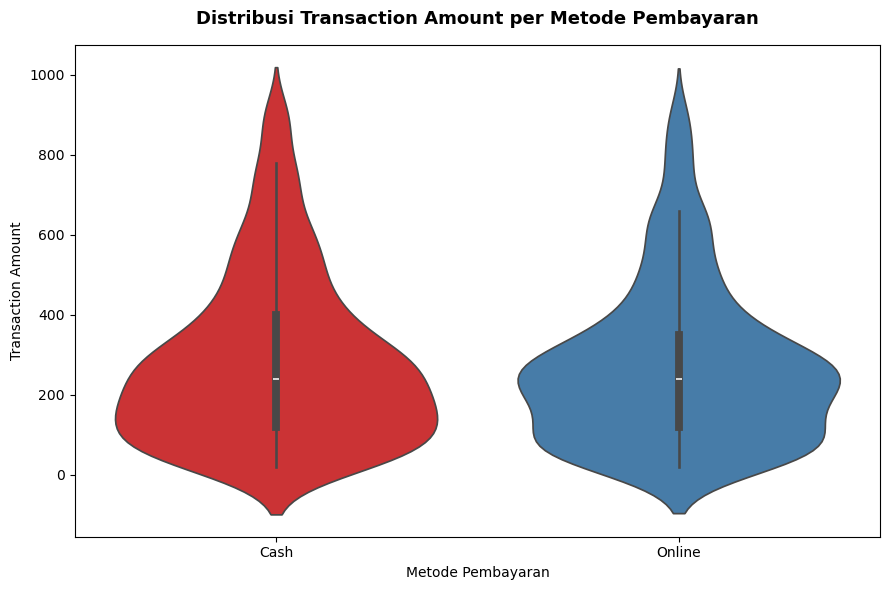

In [94]:
# Bivariate 2: Transaction Amount per Transaction Type (Violin Plot)
plt.figure(figsize=(9, 6))
sns.violinplot(
    data=dataclean_final,
    x='transaction_type',
    y='transaction_amount',
    palette='Set1',
    inner='box'
)
plt.title('Distribusi Transaction Amount per Metode Pembayaran', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Metode Pembayaran')
plt.ylabel('Transaction Amount')
plt.tight_layout()
plt.show()

##### INTERPRETASI:
Violin plot menggabungkan boxplot dan distribusi (KDE) dalam satu grafik. Lebar violin menunjukkan kepadatan data — semakin lebar, semakin banyak transaksi di rentang nilai tersebut. Dari hasil visualisasi tersebut dua violin berbeda bentuk tetapi tidak secara signifikan, berarti ada indikasi metode pembayaran mempengaruhi perilaku belanja pelanggan.


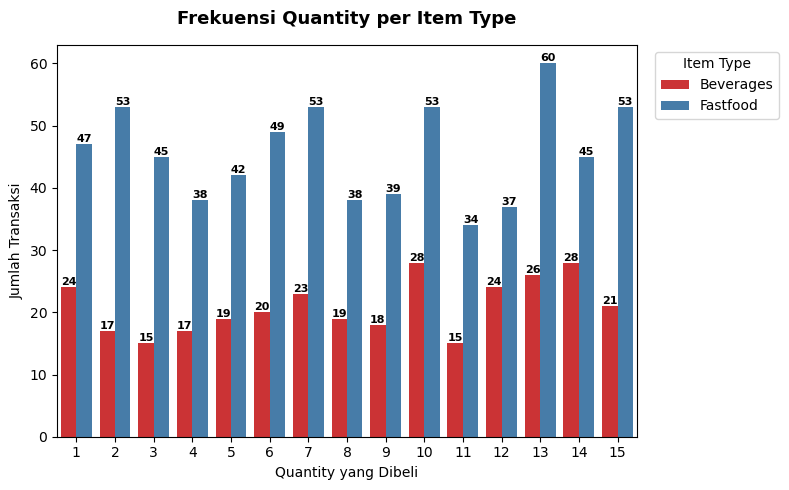

In [95]:
# Bivariate 3: Quantity vs Item Type (Count Plot)
plt.figure(figsize=(8, 5))
ax= sns.countplot(data=dataclean_final, x='quantity', hue='item_type', palette='Set1')
# ANOTASI
for p in ax.patches:

    height = p.get_height()

    if height > 0:

        ax.annotate(
            f'{int(height)}',
            (
                p.get_x() + p.get_width()/2.,
                height
            ),
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold'
        )
        
plt.title('Frekuensi Quantity per Item Type', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Quantity yang Dibeli')
plt.ylabel('Jumlah Transaksi')
plt.legend(title='Item Type', bbox_to_anchor=(1.02, 1),loc='upper left')
plt.tight_layout()
plt.show()


##### INTERPRETASI:
Count plot ini menunjukkan seberapa sering pelanggan membeli sejumlah tertentu item untuk kategori Fastfood vs Beverages.
Jika mayoritas transaksi quantity=1, pelanggan cenderung membeli satuan. Quantity tinggi yang sering muncul bisa mengindikasikan pembelian untuk keluarga/grup.

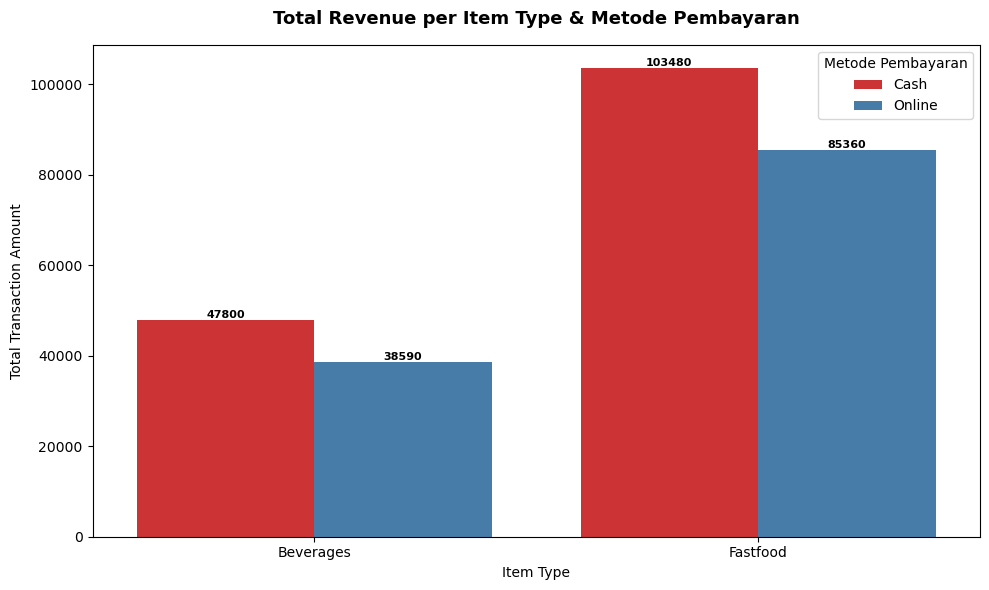

In [96]:
# Bivariate 4: Grouped Bar — Revenue per Item Type per Transaction Type
grouped_mv = dataclean.groupby(['item_type', 'transaction_type'], observed=True)['transaction_amount'].sum().reset_index()

plt.figure(figsize=(10, 6))
ax2 = sns.barplot(
    data=grouped_mv,
    x='item_type',
    y='transaction_amount',
    hue='transaction_type',
    palette='Set1'
)
# ANOTASI
for p in ax2.patches:

    height = p.get_height()

    if height > 0:

        ax2.annotate(f'{int(height)}',(p.get_x() + p.get_width()/2.,height),ha='center',va='bottom',fontsize=8,fontweight='bold')

plt.title('Total Revenue per Item Type & Metode Pembayaran', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Item Type')
plt.ylabel('Total Transaction Amount')
plt.legend(title='Metode Pembayaran')
plt.tight_layout()
plt.show()

##### INTERPRETASI:
Grafik grouped bar ini memperlihatkan perbandingan revenue antara Cash dan Online untuk setiap jenis produk (Fastfood vs Beverages). Jika Cash mendominasi di Fastfood tapi Online lebih besar di Beverages, ini bisa menjadi insight untuk strategi digitalisasi pembayaran.

In [97]:
grouped_mv

,item_type,transaction_type,transaction_amount
0,Beverages,Cash,47800
1,Beverages,Online,38590
2,Fastfood,Cash,103480
3,Fastfood,Online,85360


#### Analysis Multivariate

C:\Users\Fadlilah\anaconda3\Lib\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
C:\Users\Fadlilah\anaconda3\Lib\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
C:\Users\Fadlilah\anaconda3\Lib\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)


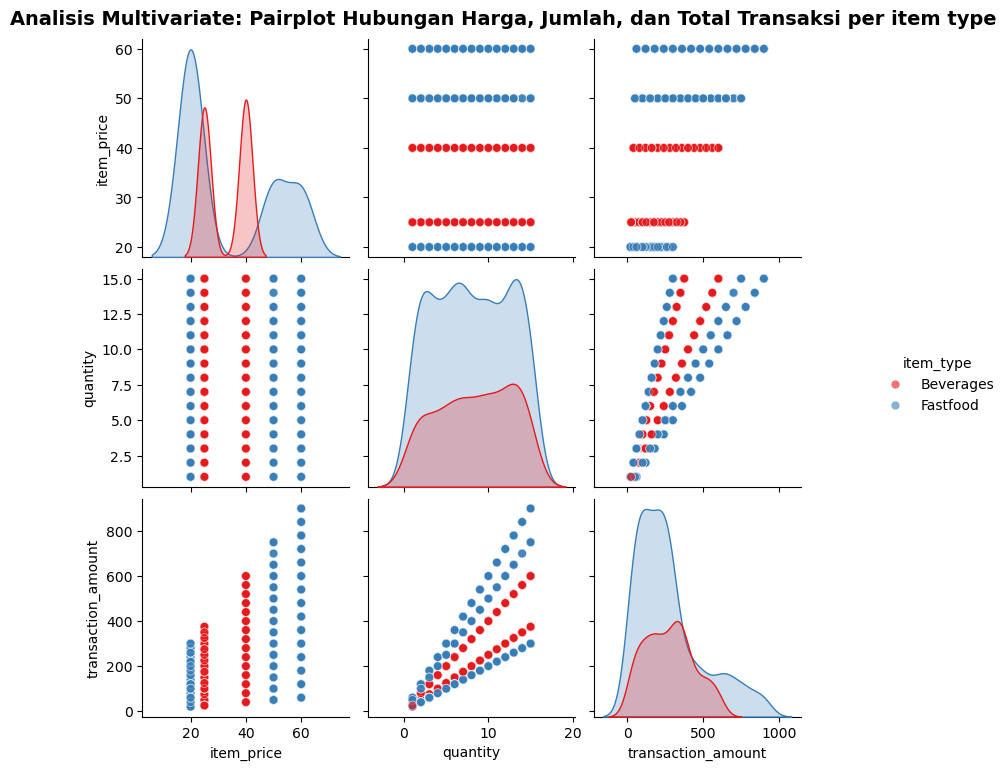

In [98]:
# Pastikan dataclean_final sudah memiliki kolom numerik yang diperlukan
# Asumsikan dataclean_final sudah didefinisikan seperti pada notebook Anda.

# Memilih kolom numerik yang relevan untuk pairplot
numeric_cols = ['item_price', 'quantity', 'transaction_amount']

# Membuat pairplot, dibedakan berdasarkan 'item_type'
# 'diag_kind' = 'kde' untuk menampilkan estimasi kepadatan pada diagonal
sns.pairplot(
    data=dataclean_final,
    vars=numeric_cols,
    hue='item_type',  # Membedakan Fastfood vs Beverages
    palette='Set1',
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 40},
    diag_kws={'shade': True}
)
plt.suptitle('Analisis Multivariate: Pairplot Hubungan Harga, Jumlah, dan Total Transaksi per item type', y=1.02, fontsize=14, fontweight='bold')
plt.show()

#### Advanced EDA Techniques

=== Cross Tabulation: Revenue per Item Type × Transaction Type ===
transaction_type    Cash  Online   Total
item_type                               
Beverages          47800   38590   86390
Fastfood          103480   85360  188840
Total             151280  123950  275230

=== Cross Tabulation: Persentase Revenue per Item Type ===
transaction_type  Cash  Online
item_type                     
Beverages         55.3    44.7
Fastfood          54.8    45.2


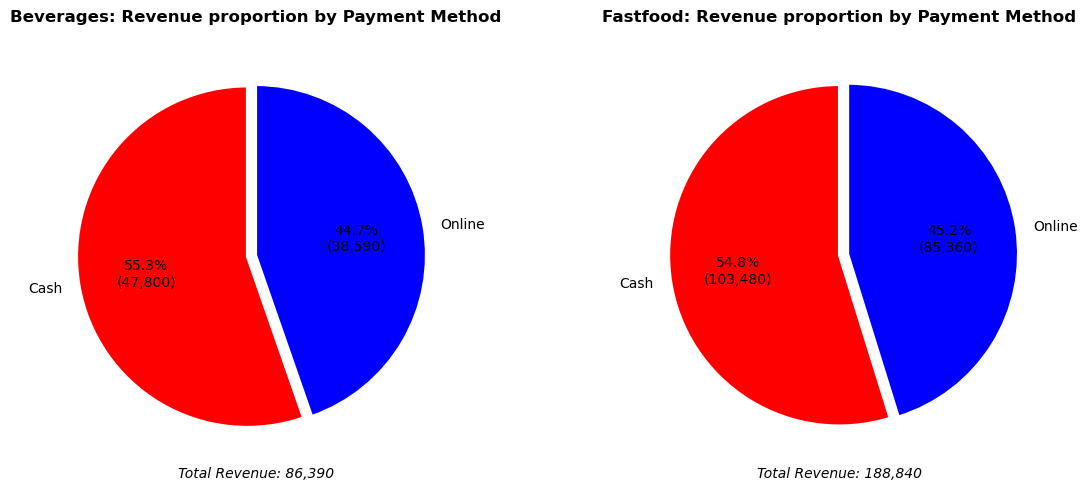


INTERPRETASI:

• Beverages: Cash 55.3% | Online 44.7%
• Fastfood: Cash 54.8% | Online 45.2%

Kesimpulan: Pola pembayaran relatif sama antara kedua jenis produk.


In [99]:
# ADVANCED EDA 1 — Cross Tabulation dengan Pie Chart (Revenue-Based)

import pandas as pd
import matplotlib.pyplot as plt

# 1. Cross Tabulation: Revenue berdasarkan Item Type & Transaction Type

# Crosstab revenue (bukan frekuensi)
ct_revenue = pd.crosstab(
    dataclean_final['item_type'],
    dataclean_final['transaction_type'],
    values=dataclean_final['transaction_amount'],
    aggfunc='sum',
    margins=True,
    margins_name='Total'
).round(0)

print('=== Cross Tabulation: Revenue per Item Type × Transaction Type ===')
print(ct_revenue)

# Crosstab persentase revenue (normalize per baris)
ct_revenue_pct = pd.crosstab(
    dataclean_final['item_type'],
    dataclean_final['transaction_type'],
    values=dataclean_final['transaction_amount'],
    aggfunc='sum',
    normalize='index'
).round(3) * 100

print('\n=== Cross Tabulation: Persentase Revenue per Item Type ===')
print(ct_revenue_pct)


# 2. Visualisasi Pie Chart (2 chart terpisah)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Warna untuk Cash dan Online
colors = ['red', 'blue']
labels = ['Cash', 'Online']

# --- Pie Chart 1: Beverages ---
beverages_revenue = ct_revenue.loc['Beverages', ['Cash', 'Online']].values
explode_beverages = (0.05, 0)  # sedikit menonjolkan Cash jika lebih kecil

axes[0].pie(
    beverages_revenue,
    labels=labels,
    autopct=lambda pct: f'{pct:.1f}%\n({pct/100 * sum(beverages_revenue):,.0f})',
    colors=colors,
    explode=explode_beverages,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Beverages: Revenue proportion by Payment Method', 
                  fontweight='bold', fontsize=12, pad=15)

# Tambahkan total revenue di tengah atau bawah
axes[0].text(0, -1.3, f"Total Revenue: {sum(beverages_revenue):,.0f}", 
             ha='center', fontsize=10, style='italic')

# --- Pie Chart 2: Fastfood ---
fastfood_revenue = ct_revenue.loc['Fastfood', ['Cash', 'Online']].values
explode_fastfood = (0, 0.05)  # sedikit menonjolkan Online jika lebih kecil

axes[1].pie(
    fastfood_revenue,
    labels=labels,
    autopct=lambda pct: f'{pct:.1f}%\n({pct/100 * sum(fastfood_revenue):,.0f})',
    colors=colors,
    explode=explode_fastfood,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Fastfood: Revenue proportion by Payment Method', 
                  fontweight='bold', fontsize=12, pad=15)

axes[1].text(0, -1.3, f"Total Revenue: {sum(fastfood_revenue):,.0f}", 
             ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.show()

# 3. Interpretasi
print("\n" + "="*60)
print("INTERPRETASI:")
print("="*60)

beverages_cash_pct = ct_revenue_pct.loc['Beverages', 'Cash']
beverages_online_pct = ct_revenue_pct.loc['Beverages', 'Online']
fastfood_cash_pct = ct_revenue_pct.loc['Fastfood', 'Cash']
fastfood_online_pct = ct_revenue_pct.loc['Fastfood', 'Online']

print(f"""
• Beverages: Cash {beverages_cash_pct:.1f}% | Online {beverages_online_pct:.1f}%
• Fastfood: Cash {fastfood_cash_pct:.1f}% | Online {fastfood_online_pct:.1f}%
""")

if abs(beverages_online_pct - fastfood_online_pct) > 10:
    print("Kesimpulan: Ada perbedaan signifikan preferensi pembayaran antara Beverages dan Fastfood.")
    if beverages_online_pct > fastfood_online_pct:
        print("Pelanggan Beverages lebih cenderung menggunakan Online Payment.")
    else:
        print("Pelanggan Fastfood lebih cenderung menggunakan Online Payment.")
else:
    print("Kesimpulan: Pola pembayaran relatif sama antara kedua jenis produk.")

Grouping Lanjutan: Item Type × Time of Sale × Transaction Type
    item_type time_of_sale transaction_type  total_revenue  avg_revenue  \
18   Fastfood        Night             Cash          24410       343.80   
14   Fastfood     Midnight             Cash          22650       286.71   
19   Fastfood        Night           Online          20030       294.56   
12   Fastfood      Evening             Cash          19280       244.05   
10   Fastfood    Afternoon             Cash          19250       278.99   
17   Fastfood      Morning           Online          19210       300.16   
16   Fastfood      Morning             Cash          17890       259.28   
13   Fastfood      Evening           Online          16600       276.67   
11   Fastfood    Afternoon           Online          15490       253.93   
15   Fastfood     Midnight           Online          14030       212.58   
1   Beverages    Afternoon           Online          12460       296.67   
8   Beverages        Night           

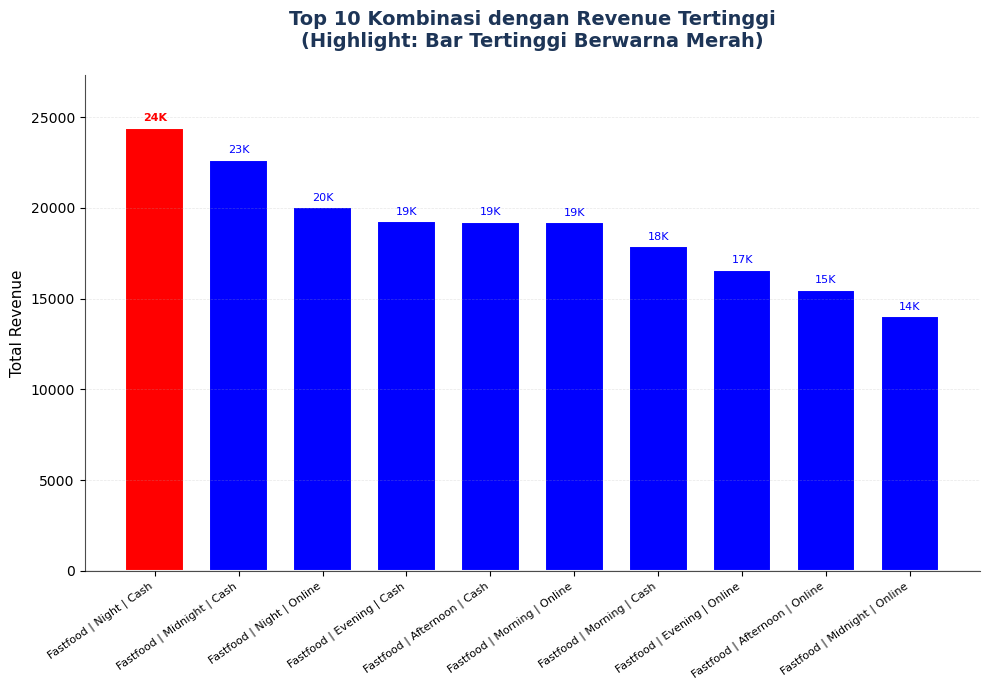


DETAIL NILAI TOP 10 KOMBINASI:
⭐ 1. Fastfood | Night | Cash: Rp24,410
   2. Fastfood | Midnight | Cash: Rp22,650
   3. Fastfood | Night | Online: Rp20,030
   4. Fastfood | Evening | Cash: Rp19,280
   5. Fastfood | Afternoon | Cash: Rp19,250
   6. Fastfood | Morning | Online: Rp19,210
   7. Fastfood | Morning | Cash: Rp17,890
   8. Fastfood | Evening | Online: Rp16,600
   9. Fastfood | Afternoon | Online: Rp15,490
   10. Fastfood | Midnight | Online: Rp14,030

INTERPRETASI:
Grouping multikolom mengungkap kombinasi kondisi yang menghasilkan revenue tertinggi.
Kombinasi dengan bar MERAH adalah yang paling dominan secara revenue.
Kombinasi ini bisa dijadikan prioritas promosi atau pengembangan produk.



In [100]:
# ADVANCED EDA 2 — Grouping & Aggregasi Lanjutan
# 1. Grouping data
group_adv = dataclean_final.groupby(
    ['item_type', 'time_of_sale', 'transaction_type'],
    observed=True
).agg(
    total_revenue=('transaction_amount', 'sum'),
    avg_revenue=('transaction_amount', 'mean'),
    total_quantity=('quantity', 'sum'),
    jumlah_transaksi=('order_id', 'count')
).round(2).reset_index()

print('Grouping Lanjutan: Item Type × Time of Sale × Transaction Type')
print(group_adv.sort_values('total_revenue', ascending=False).head(15))

# 2. Ambil top 10 kombinasi
top_group = group_adv.sort_values('total_revenue', ascending=False).head(10).copy()
top_group['label'] = (
    top_group['item_type'].astype(str) + ' | ' + 
    top_group['time_of_sale'].astype(str) + ' | ' + 
    top_group['transaction_type'].astype(str)
)

# 3. Buat warna: merah untuk bar tertinggi, biru untuk sisanya
colors = ['red' if i == 0 else 'blue' for i in range(len(top_group))]

# 4. Visualisasi dengan ukuran proporsional
# Hitung proporsi lebar figure berdasarkan jumlah label
fig_width = max(10, len(top_group) * 0.8)  # Minimal 10 inch, tambah 0.8 per bar
fig_height = 7  # Tinggi tetap nyaman

plt.figure(figsize=(fig_width, fig_height))

# Buat bar chart
bars = plt.bar(
    x=range(len(top_group)),  # pakai index agar lebih rapi
    height=top_group['total_revenue'],
    color=colors,
    edgecolor='white',
    linewidth=1.5,
    width=0.7
)

# 5. Tambahkan notasi nilai pada SEMUA bar
max_revenue = top_group['total_revenue'].max()

for i, (idx, row) in enumerate(top_group.iterrows()):
    revenue = row['total_revenue']
    bar_height = revenue
    
    # Format nilai 
    if revenue >= 1_000_000:
        value_label = f'{revenue/1_000_000:.1f}M'
    elif revenue >= 1_000:
        value_label = f'{revenue/1_000:.0f}K'
    else:
        value_label = f'{revenue:.0f}'
    
    # Posisi label: di atas bar
    y_pos = bar_height + (max_revenue * 0.01)  # 1% dari max revenue sebagai offset
    
    # Warna label: merah untuk bar tertinggi, abu-abu tua untuk lainnya
    label_color = 'red' if i == 0 else 'blue'
    
    # Tambahkan teks
    plt.text(
        i, y_pos,
        value_label,
        ha='center', 
        va='bottom', 
        fontweight='bold' if i == 0 else 'normal',
        fontsize=9 if len(top_group) <= 8 else 8,
        color=label_color,
        rotation=0
    )

# ============================================
# 6. Setting label dan title
# ============================================
plt.xticks(
    ticks=range(len(top_group)),
    labels=top_group['label'],
    rotation=35,  # rotated agar tidak terlalu miring
    ha='right',
    fontsize=9 if len(top_group) <= 8 else 8
)

plt.title('Top 10 Kombinasi dengan Revenue Tertinggi\n(Highlight: Bar Tertinggi Berwarna Merah)', 
          fontsize=14, fontweight='bold', pad=20, color='#1D3557')
plt.ylabel('Total Revenue', fontsize=11, fontweight='medium')
plt.xlabel('')

# Tambahkan grid di sumbu Y (membantu membaca nilai)
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)

# Sesuaikan batas atas sumbu Y (memberi ruang untuk label)
plt.ylim(0, max_revenue * 1.12)  # 12% ruang di atas bar tertinggi

# Tambahkan garis horizontal tipis di sumbu X
plt.axhline(y=0, color='black', linewidth=0.8)

# Hapus border atas dan kanan
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_alpha(0.7)
ax.spines['bottom'].set_alpha(0.7)

plt.tight_layout()
plt.show()

# 7. Cetak detail nilai untuk verifikasi

print("\n" + "="*70)
print("DETAIL NILAI TOP 10 KOMBINASI:")
print("="*70)
for i, (idx, row) in enumerate(top_group.iterrows()):
    star = "⭐ " if i == 0 else "   "
    print(f"{star}{i+1}. {row['label']}: Rp{row['total_revenue']:,.0f}")
print("="*70)

print("""
INTERPRETASI:
Grouping multikolom mengungkap kombinasi kondisi yang menghasilkan revenue tertinggi.
Kombinasi dengan bar MERAH adalah yang paling dominan secara revenue.
Kombinasi ini bisa dijadikan prioritas promosi atau pengembangan produk.
""")

Threshold transaksi high-value (Q3): 360.00
Jumlah transaksi high-value: 263 dari 1000 (26.3%)

Distribusi item pada transaksi high-value:
item_name
Sandwich           95
Cold coffee        84
Frankie            75
Sugarcane juice     9
Aalopuri            0
Panipuri            0
Vadapav             0
Name: count, dtype: int64


C:\Users\Fadlilah\AppData\Local\Temp\ipykernel_16840\3183261164.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=hv_item, x='item_name', y='count', palette='Reds_r')


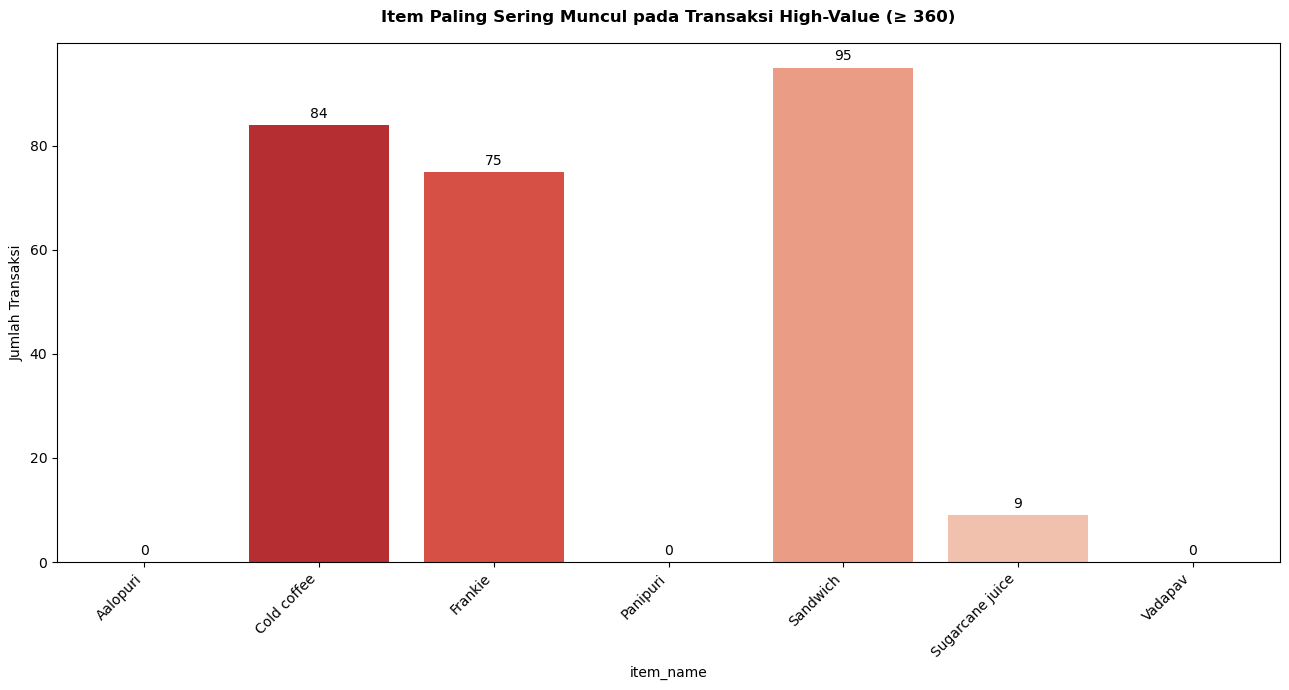


INTERPRETASI:
Filtering transaksi high-value (25% teratas) menampilkan item yang paling sering
dibeli dalam transaksi bernilai besar.
Item yang dominan di kelompok ini adalah produk premium yang perlu dijaga
ketersediaannya dan bisa dijadikan upsell target.



In [101]:
# ADVANCED EDA 3 — Filtering: Transaksi High-Value
threshold = dataclean_final['transaction_amount'].quantile(0.75)  # Atas 25%
high_value = dataclean_final[dataclean_final['transaction_amount'] >= threshold]

print(f'Threshold transaksi high-value (Q3): {threshold:.2f}')
print(f'Jumlah transaksi high-value: {len(high_value)} dari {len(dataclean)} ({len(high_value)/len(dataclean)*100:.1f}%)')
print('\nDistribusi item pada transaksi high-value:')
print(high_value['item_name'].value_counts())

plt.figure(figsize=(13, 7))
hv_item = high_value['item_name'].value_counts().reset_index()
hv_item.columns = ['item_name', 'count']
ax = sns.barplot(data=hv_item, x='item_name', y='count', palette='Reds_r')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)
plt.title(f'Item Paling Sering Muncul pada Transaksi High-Value (≥ {threshold:.0f})', fontsize=12, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Jumlah Transaksi')
plt.tight_layout()
plt.show()

print("""
INTERPRETASI:
Filtering transaksi high-value (25% teratas) menampilkan item yang paling sering
dibeli dalam transaksi bernilai besar.
Item yang dominan di kelompok ini adalah produk premium yang perlu dijaga
ketersediaannya dan bisa dijadikan upsell target.
""")

In [102]:
dataclean_final[dataclean_final['transaction_amount']>=360]

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
10,11,2022-12-01,Frankie,Fastfood,50,8,400,Online,Mrs.,Afternoon
15,16,2022-04-14,Sandwich,Fastfood,60,11,660,Online,Mrs.,Midnight
19,20,2022-09-15,Cold coffee,Beverages,40,10,400,Online,Mr.,Night
20,21,2022-12-21,Cold coffee,Beverages,40,15,600,Cash,Mr.,Evening
26,27,2022-10-12,Cold coffee,Beverages,40,11,440,Online,Mrs.,Afternoon
...,...,...,...,...,...,...,...,...,...,...
988,989,2022-10-11,Cold coffee,Beverages,40,13,520,Cash,Mr.,Afternoon
990,991,2023-01-18,Sandwich,Fastfood,60,7,420,Cash,Mrs.,Night
995,996,2023-03-19,Frankie,Fastfood,50,10,500,Cash,Mrs.,Evening
996,997,2022-09-20,Sandwich,Fastfood,60,7,420,Online,Mr.,Evening


In [103]:
# Filter untuk Cold Coffee dengan amount >= 360
cold_coffee_high = dataclean_final[
    (dataclean_final['item_name'] == 'Cold coffee') & 
    (dataclean_final['transaction_amount'] >= 360)
]

print(f"Jumlah Cold Coffee dengan transaction_amount >= 360: {len(cold_coffee_high)}")

Jumlah Cold Coffee dengan transaction_amount >= 360: 84


In [104]:
# Filter untuk Cold Coffee dengan amount >= 360
cold_coffee_high = dataclean_final[
    (dataclean_final['item_name'] == 'Sandwich') & 
    (dataclean_final['transaction_amount'] >= 360)
]

print(f"Jumlah Cold Coffee dengan transaction_amount >= 360: {len(cold_coffee_high)}")

Jumlah Cold Coffee dengan transaction_amount >= 360: 95


In [105]:
# Filter untuk Cold Coffee dengan amount >= 360
cold_coffee_high = dataclean_final[
    (dataclean_final['item_name'] == 'Frankie') & 
    (dataclean_final['transaction_amount'] >= 360)
]

print(f"Jumlah Cold Coffee dengan transaction_amount >= 360: {len(cold_coffee_high)}")

Jumlah Cold Coffee dengan transaction_amount >= 360: 75


In [106]:
# Filter untuk Cold Coffee dengan amount >= 360
cold_coffee_high = dataclean_final[
    (dataclean_final['item_name'] == 'Sugarcane juice') & 
    (dataclean_final['transaction_amount'] >= 360)
]

print(f"Jumlah Cold Coffee dengan transaction_amount >= 360: {len(cold_coffee_high)}")

Jumlah Cold Coffee dengan transaction_amount >= 360: 9


Ukuran data asli: 1000
Ukuran sampel acak: 200

Statistik sampel vs populasi:
                    Populasi (Mean)  Sampel (Mean)  Selisih (%)
transaction_amount           275.23         283.85         3.13
quantity                       8.16           8.34         2.18
item_price                    33.32          33.88         1.68


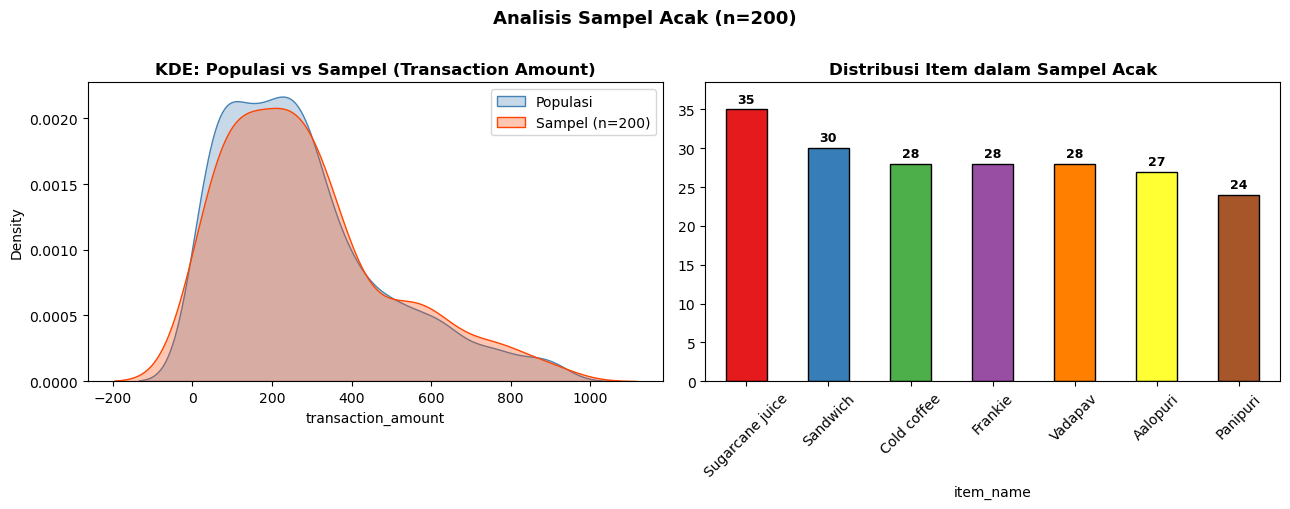

In [107]:
# ADVANCED EDA 4 — Sampling Acak
np.random.seed(42)
sample_data = dataclean_final.sample(n=200, random_state=42)

print(f'Ukuran data asli: {len(dataclean)}')
print(f'Ukuran sampel acak: {len(sample_data)}')
print(f'\nStatistik sampel vs populasi:')

comparison = pd.DataFrame({
    'Populasi (Mean)': dataclean[['transaction_amount', 'quantity', 'item_price']].mean().round(2),
    'Sampel (Mean)': sample_data[['transaction_amount', 'quantity', 'item_price']].mean().round(2),
    'Selisih (%)': ((sample_data[['transaction_amount', 'quantity', 'item_price']].mean() - 
                    dataclean_final[['transaction_amount', 'quantity', 'item_price']].mean()) / 
                   dataclean_final[['transaction_amount', 'quantity', 'item_price']].mean() * 100).round(2)
})
print(comparison)

# Visualisasi distribusi sampel vs populasi
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.kdeplot(dataclean_final['transaction_amount'], ax=axes[0], label='Populasi', fill=True, alpha=0.3, color='steelblue')
sns.kdeplot(sample_data['transaction_amount'], ax=axes[0], label='Sampel (n=200)', fill=True, alpha=0.3, color='orangered')
axes[0].set_title('KDE: Populasi vs Sampel (Transaction Amount)', fontweight='bold')
axes[0].legend()

item_counts= sample_data['item_name'].value_counts()
bars= item_counts.plot(kind='bar', ax=axes[1], color=sns.color_palette('Set1', 10), edgecolor='black')
axes[1].set_title('Distribusi Item dalam Sampel Acak', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

# Anotasi angka di atas bar
for i, (item, count) in enumerate(item_counts.items()):
    axes[1].text(i, count + 0.5, str(count), ha='center', va='bottom', fontweight='bold', fontsize=9)

axes[1].set_ylim(0, item_counts.max() + (item_counts.max() * 0.1))
plt.suptitle('Analisis Sampel Acak (n=200)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

###### INTERPRETASI:
Sampel acak sebesar 200 baris diambil dari total populasi.
Tabel selisih menunjukkan bahwa rata-rata sampel mendekati rata-rata populasi (selisih kecil),
artinya sampel ini cukup representatif untuk analisis lebih lanjut.
KDE plot memperlihatkan kesamaan bentuk distribusi antara sampel dan populasi.

#### Insight & Kesimpulan

In [108]:
# Ringkasan statistik kunci untuk kesimpulan
print('RINGKASAN INSIGHT UTAMA')

top_item_revenue = dataclean_final.groupby('item_name', observed=True)['transaction_amount'].sum().idxmax()
top_item_qty = dataclean_final.groupby('item_name', observed=True)['quantity'].sum().idxmax()
top_time = dataclean_final.groupby('time_of_sale', observed=True)['transaction_amount'].sum().idxmax()
cash_rev = dataclean_final[dataclean_final['transaction_type']=='Cash']['transaction_amount'].sum()
online_rev = dataclean_final[dataclean_final['transaction_type']=='Online']['transaction_amount'].sum()

print(f'Item dengan Revenue Tertinggi  : {top_item_revenue}')
print(f'Item dengan Quantity Terbanyak : {top_item_qty}')
print(f'Waktu Penjualan Terbaik        : {top_time}')
print(f'Revenue Cash                   : {cash_rev:,.0f}')
print(f'Revenue Online                 : {online_rev:,.0f}')
print(f'Dominasi Pembayaran            : {"Cash" if cash_rev > online_rev else "Online"}')

RINGKASAN INSIGHT UTAMA
Item dengan Revenue Tertinggi  : Sandwich
Item dengan Quantity Terbanyak : Cold coffee
Waktu Penjualan Terbaik        : Night
Revenue Cash                   : 151,280
Revenue Online                 : 123,950
Dominasi Pembayaran            : Cash


##### Tambahan

In [109]:
from scipy.stats import shapiro

# transaction amount
stat1, p1 = shapiro(dataclean_final['transaction_amount'])

# quantity
stat2, p2 = shapiro(dataclean_final['quantity'])

print('P-value Transaction Amount:', p1)
print('P-value Quantity:', p2)

P-value Transaction Amount: 5.4820844710665364e-24
P-value Quantity: 1.0344615736024162e-19


In [110]:
from scipy.stats import spearmanr

corr, p_value = spearmanr(
    dataclean_final['quantity'],
    dataclean_final['transaction_amount']
)

print('Correlation:', corr)
print('P-value:', p_value)

alpha = 0.05

if p_value<alpha: #Tolak H0
    print("hasil signifikan: ada hubungan signifikan antara quantity dan transaction amount")

else: #gagal menolak H0
    print("hasil tidak signifikan: tidak ada hubungan signifikan antara quantity dan transaction amount")

Correlation: 0.8064271045085807
P-value: 6.085501337536874e-230
hasil signifikan: ada hubungan signifikan antara quantity dan transaction amount


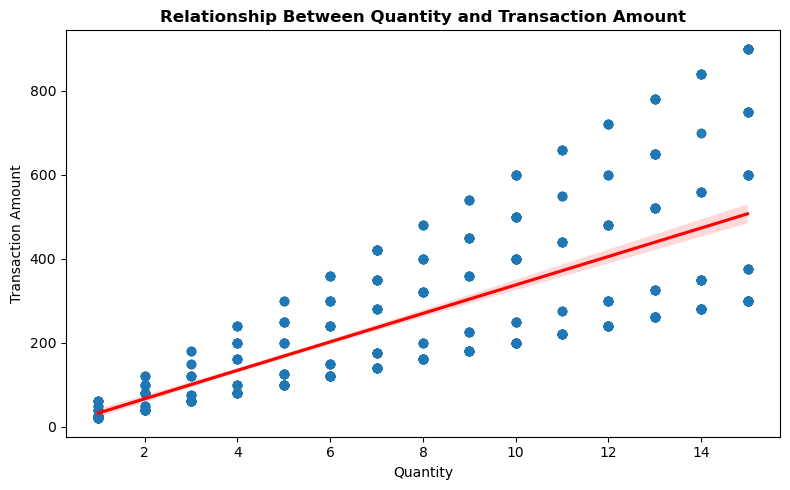

In [111]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=dataclean_final,
    x='quantity',
    y='transaction_amount',
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'}
)

plt.title(
    'Relationship Between Quantity and Transaction Amount',
    fontweight='bold'
)

plt.xlabel('Quantity')

plt.ylabel('Transaction Amount')

plt.tight_layout()

plt.show()

In [112]:
from scipy.stats import spearmanr

corr, p_value = spearmanr(
    dataclean_final['item_price'],
    dataclean_final['transaction_amount']
)

print('Correlation:', corr)
print('P-value:', p_value)

alpha = 0.05

if p_value<alpha: #Tolak H0
    print("hasil signifikan: ada hubungan signifikan antara item_price dan transaction amount")

else: #gagal menolak H0
    print("hasil tidak signifikan: tidak ada hubungan signifikan antara item_price dan transaction amount")

Correlation: 0.5797574842405648
P-value: 7.265746413718345e-91
hasil signifikan: ada hubungan signifikan antara item_price dan transaction amount
